<a href="https://colab.research.google.com/github/Ksh1t1zsharma/Local-Food-Wastage-Management-System/blob/main/Local_Food_Wastage_Management_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Local Food Wastage Management System**

##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

This document provides a comprehensive account of the progressive development of a Streamlit application intended to function as a thorough local food wastage management system. The primary objective of this project is to create a dynamic platform that effectively connects food providers with individuals and organizations in need, thereby facilitating the efficient redistribution of surplus food. This initiative is motivated by the dual aims of significantly reducing food waste and providing essential support to communities.

The proposed Streamlit application is designed to feature a robust array of functionalities, ensuring a rich and interactive user experience. The key components central to the application's design are as follows:

* **Insightful Data Visualization:** The application is constructed to interface with a SQLite database, which serves as the central repository for all pertinent data. A fundamental feature includes the execution and clear presentation of the outputs from 15 predefined SQL queries. These queries are formulated to extract valuable insights from the stored data, encompassing various aspects of food listings, provider and receiver activities, and claim statuses. The results will be displayed in a user-friendly format, incorporating graphical visualizations where appropriate to highlight trends, patterns, and key statistics at a glance.

* **Advanced Filtering Capabilities:** To enhance usability and efficiency, the application will integrate sophisticated filtering options. Users will be able to easily refine food listings based on multiple criteria. These criteria will include filtering by the city where the food is available, the specific provider offering the donation, the type of food being provided (e.g., vegetarian, non-vegetarian), and the designated meal type (e.g., breakfast, lunch, dinner). This targeted filtering will enable seekers to swiftly locate food donations that best match their requirements.

* **Direct Communication Facilitation:** Recognizing the significance of direct interaction in successful food redistribution, the application will provide readily accessible contact details for both food providers and receivers. This feature is designed to streamline the coordination process, enabling parties to communicate directly to arrange logistics for food pickup or delivery, thereby fostering a more efficient and collaborative system.

* **Comprehensive Data Management (CRUD Operations):** A cornerstone of the application's functionality is the implementation of full Create, Read, Update, and Delete (CRUD) operations. This functionality will allow administrators and authorized users to manage the core data within the system directly through the Streamlit interface. This includes the ability to add new records for providers, receivers, and food listings, view existing records, modify necessary details, and remove outdated or incorrect entries. Robust claims management, encompassing the tracking of food claim statuses (pending, completed, cancelled), is also being integrated with complete CRUD support.

* **Integrated Analytics Section:** A dedicated section for analytics and SQL queries is planned. This area will not only present the results of the 15 key SQL queries but may also offer additional tools for data exploration. The visualizations generated from the query results will serve as a vital component of this section, assisting users and administrators in gaining a deeper understanding of the food wastage landscape and the impact of redistribution efforts.

* **Future Expansion with EDA and Predictions:** Looking forward, the application is being developed with the potential for integrating results from Exploratory Data Analysis (EDA) to uncover further insights and patterns within the data. There is also the expectation for incorporating predictive models, which may assist in forecasting food availability or demand, further optimizing the redistribution process.

The development process adheres to a structured, multi-step plan that ensures systematic construction and integration of each component. Significant progress has been achieved in establishing foundational elements, including the basic layout of the application, the navigation structure, and the essential functions required for database connectivity and query execution. A crucial milestone that has been successfully reached is the saving of the current state of the Streamlit application code to an `app.py` file. This file now encompasses the core framework, prepared for the subsequent steps of implementing the detailed features outlined in the development plan. This document serves as a transparent record of the ongoing project aimed at building a functional and impactful local food wastage management system.

# **GitHub Link -**

https://github.com/Ksh1t1zsharma

# **Problem Statement**


Inefficient management and redistribution of surplus food at the local level significantly contribute to food wastage while leaving vulnerable populations without adequate access to nutrition. The existing processes that connect food providers—such as restaurants, grocery stores, and catering services—with food seekers, including non-governmental organizations (NGOs), community centers, and individuals, are often fragmented, manual, and lack real-time information. Consequently, valuable surplus food is wasted rather than efficiently directed to those in need. There is a pressing need for a centralized, accessible, and user-friendly platform capable of streamlining the processes of listing, discovering, claiming, and managing surplus food donations within local communities.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
# Data Manipulation and Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical Analysis and Hypothesis Testing
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, kruskal
import scipy.stats as stats

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, chi2, RFE, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Model Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, classification_report, confusion_matrix,
                           roc_curve, auc, roc_auc_score)

# Model Interpretation
import shap
from sklearn.inspection import permutation_importance

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Model Persistence
import pickle
import joblib

# Time and Date Operations
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plotting style
plt.style.use('default')
sns.set_palette("husl")

# Sql Analysis
import sqlite3
import sqlalchemy

# Streamlit deployment
!pip install streamlit ngrok pyngrok
import streamlit as st

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 12.7 MB/s eta 0:00:00


### Dataset Loading

In [ ]:
# Load Dataset

import pandas as pd
import numpy as np

# Direct download URLs (converted from your share links)
providers_url = "https://drive.google.com/uc?export=download&id=1nYaJUVwb9WzDiWlW15rfiIDCELYImx__"
receivers_url = "https://drive.google.com/uc?export=download&id=1hw330IEaPUl7N9Jcm3IsyFoX8Ti5PyS6"
food_listings_url = "https://drive.google.com/uc?export=download&id=1hZ7w3YtNQqFRmfzV6sQ8QfCXVGnlei_m"
claims_url = "https://drive.google.com/uc?export=download&id=1G-qlvSwaiVo-8cSxCbSoXBNYL2OYUN6x"

# Load the datasets
try:
    providers_df = pd.read_csv(providers_url)
    receivers_df = pd.read_csv(receivers_url)
    food_listings_df = pd.read_csv(food_listings_url)
    claims_df = pd.read_csv(claims_url)

    print("✅ All datasets loaded successfully!")
except Exception as e:
    print(f"❌ Error loading datasets: {e}")
    print("Please try Method 2 or 3 below")

✅ All datasets loaded successfully!


In [ ]:
# verification of loaded datasets
print(" DATASET OVERVIEW ")

datasets = {
    'Providers': providers_df,
    'Receivers': receivers_df,
    'Food Listings': food_listings_df,
    'Claims': claims_df
}

for name, df in datasets.items():
    print(f"\n{name} Dataset:")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows of each dataset
print("\n SAMPLE DATA ")
for name, df in datasets.items():
    print(f"\n{name} - First 3 rows:")
    print(df.head(3))

 DATASET OVERVIEW 

Providers Dataset:
  Shape: (1000, 6)
  Columns: ['Provider_ID', 'Name', 'Type', 'Address', 'City', 'Contact']
  Memory usage: 0.34 MB

Receivers Dataset:
  Shape: (1000, 5)
  Columns: ['Receiver_ID', 'Name', 'Type', 'City', 'Contact']
  Memory usage: 0.24 MB

Food Listings Dataset:
  Shape: (1000, 9)
  Columns: ['Food_ID', 'Food_Name', 'Quantity', 'Expiry_Date', 'Provider_ID', 'Provider_Type', 'Location', 'Food_Type', 'Meal_Type']
  Memory usage: 0.36 MB

Claims Dataset:
  Shape: (1000, 5)
  Columns: ['Claim_ID', 'Food_ID', 'Receiver_ID', 'Status', 'Timestamp']
  Memory usage: 0.14 MB

 SAMPLE DATA 

Providers - First 3 rows:
   Provider_ID                         Name           Type  \
0            1             Gonzales-Cochran    Supermarket   
1            2  Nielsen, Johnson and Fuller  Grocery Store   
2            3                 Miller-Black    Supermarket   

                                             Address            City  \
0  74347 Christopher Ext

### Dataset First View

In [ ]:
# Dataset First Look
print("Dataset First Look:")
print("Providers Data:")
print(providers_df.head())
print("\nReceivers Data:")
print(receivers_df.head())
print("\nFood Listings Data:")
print(food_listings_df.head())
print("\nClaims Data:")
print(claims_df.head())

Dataset First Look:
Providers Data:
   Provider_ID                         Name           Type  \
0            1             Gonzales-Cochran    Supermarket   
1            2  Nielsen, Johnson and Fuller  Grocery Store   
2            3                 Miller-Black    Supermarket   
3            4   Clark, Prince and Williams  Grocery Store   
4            5               Coleman-Farley  Grocery Store   

                                             Address            City  \
0  74347 Christopher Extensions\nAndreamouth, OK ...     New Jessica   
1           91228 Hanson Stream\nWelchtown, OR 27136     East Sheena   
2  561 Martinez Point Suite 507\nGuzmanchester, W...  Lake Jesusview   
3     467 Bell Trail Suite 409\nPort Jesus, IA 61188     Mendezmouth   
4  078 Matthew Creek Apt. 319\nSaraborough, MA 53978   Valentineside   

                Contact  
0       +1-600-220-0480  
1  +1-925-283-8901x6297  
2      001-517-295-2206  
3      556.944.8935x401  
4          193.714.6577  

R

### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print("Dataset Rows & Columns count:")
print("Providers rows and columns:")
print(providers_df.shape)
print("\nReceivers rows and columns:")
print(receivers_df.shape)
print("\nFood Listings rows and columns:")
print(food_listings_df.shape)
print("\nClaims rows and columns:")
print(claims_df.shape)

Dataset Rows & Columns count:
Providers rows and columns:
(1000, 6)

Receivers rows and columns:
(1000, 5)

Food Listings rows and columns:
(1000, 9)

Claims rows and columns:
(1000, 5)


### Dataset Information

In [ ]:
# Dataset Info
print("Dataset Info:")
print("Providers Data:")
print(providers_df.info())
print("\nReceivers Data:")
print(receivers_df.info())
print("\nFood Listings Data:")
print(food_listings_df.info())
print("\nClaims Data:")
print(claims_df.info())

Dataset Info:
Providers Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Provider_ID  1000 non-null   int64 
 1   Name         1000 non-null   object
 2   Type         1000 non-null   object
 3   Address      1000 non-null   object
 4   City         1000 non-null   object
 5   Contact      1000 non-null   object
dtypes: int64(1), object(5)
memory usage: 47.0+ KB
None

Receivers Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Receiver_ID  1000 non-null   int64 
 1   Name         1000 non-null   object
 2   Type         1000 non-null   object
 3   City         1000 non-null   object
 4   Contact      1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB
None

Food Listings D

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print("Dataset Duplicate Value Count:")
print("Providers Duplicate Values:")
print(providers_df.duplicated().sum())
print("\nReceivers Duplicate Values:")
print(receivers_df.duplicated().sum())
print("\nFood Listings Duplicate Values:")
print(food_listings_df.duplicated().sum())
print("\nClaims Duplicate Values:")
print(claims_df.duplicated().sum())

Dataset Duplicate Value Count:
Providers Duplicate Values:
0

Receivers Duplicate Values:
0

Food Listings Duplicate Values:
0

Claims Duplicate Values:
0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count\
print("Missing Values/Null Values Count:")
print("Providers Missing Values:")
print(providers_df.isnull().sum())
print("\nReceivers Missing Values:")
print(receivers_df.isnull().sum())
print("\nFood Listings Missing Values:")
print(food_listings_df.isnull().sum())
print("\nClaims Missing Values:")
print(claims_df.isnull().sum())

Missing Values/Null Values Count:
Providers Missing Values:
Provider_ID    0
Name           0
Type           0
Address        0
City           0
Contact        0
dtype: int64

Receivers Missing Values:
Receiver_ID    0
Name           0
Type           0
City           0
Contact        0
dtype: int64

Food Listings Missing Values:
Food_ID          0
Food_Name        0
Quantity         0
Expiry_Date      0
Provider_ID      0
Provider_Type    0
Location         0
Food_Type        0
Meal_Type        0
dtype: int64

Claims Missing Values:
Claim_ID       0
Food_ID        0
Receiver_ID    0
Status         0
Timestamp      0
dtype: int64


Visualizing the missing values


<function matplotlib.pyplot.show(close=None, block=None)>

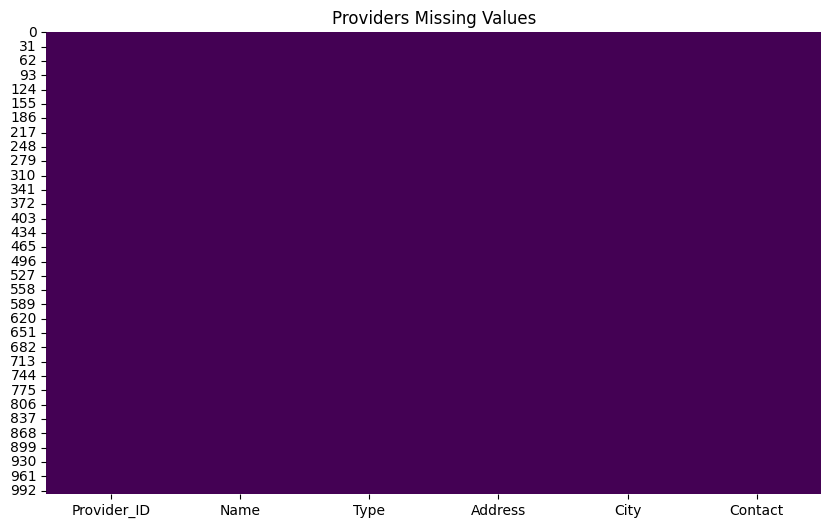

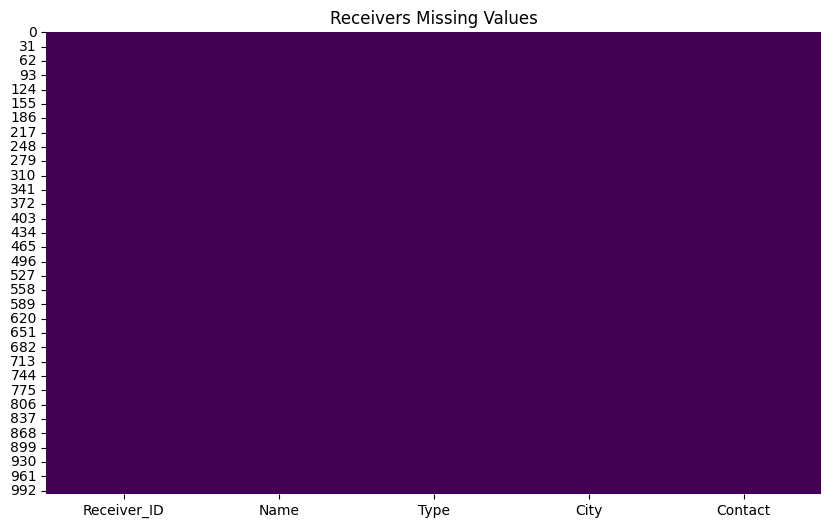

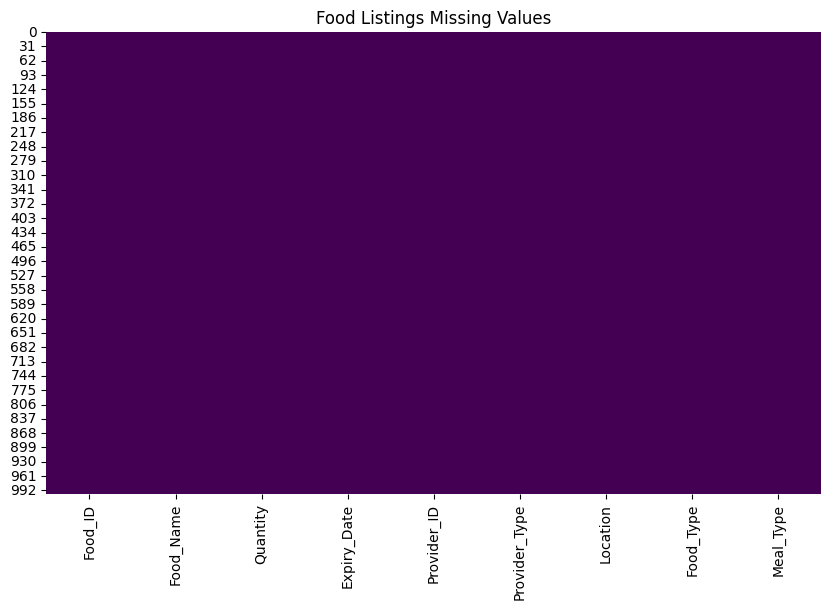

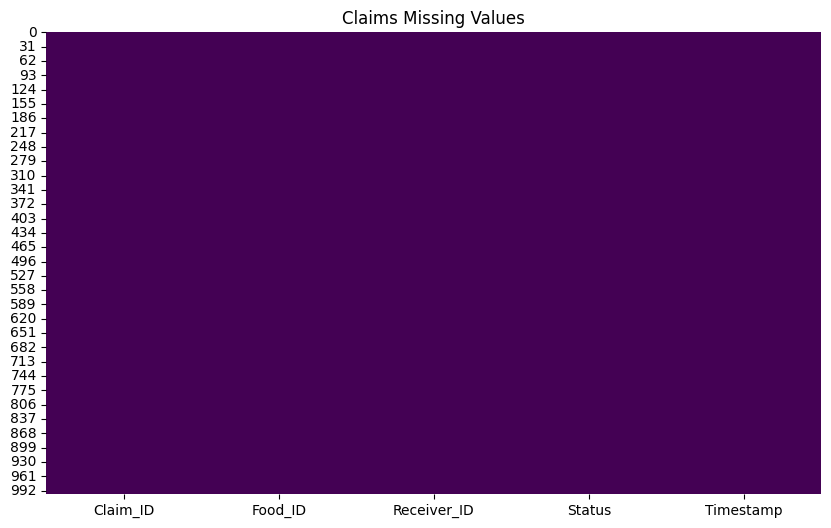

In [ ]:
# Visualizing the missing values
print("Visualizing the missing values")

plt.figure(figsize=(10, 6))
sns.heatmap(providers_df.isnull(), cbar=False, cmap='viridis')
plt.title('Providers Missing Values')
plt.show
plt.figure(figsize=(10, 6))
sns.heatmap(receivers_df.isnull(), cbar=False, cmap='viridis')
plt.title('Receivers Missing Values')
plt.show
plt.figure(figsize=(10, 6))
sns.heatmap(food_listings_df.isnull(), cbar=False, cmap='viridis')
plt.title('Food Listings Missing Values')
plt.show
plt.figure(figsize=(10, 6))
sns.heatmap(claims_df.isnull(), cbar=False, cmap='viridis')
plt.title('Claims Missing Values')
plt.show

### What did you know about your dataset?

- The dataset for this project is stored in a SQLite database named `food_management.db`, organized into several essential tables for managing food wastage:

 - **`providers`**: Contains details about food donors, including `Provider_ID`, `Name`, `Type` (e.g., Restaurant, Grocery Store), `Address`, and `Contact`.

 - **`receivers`**: Stores information about recipients of food donations, featuring `Receiver_ID`, `Name`, `Type` (e.g., NGO, Shelter), `City`, and `Contact`.

 - **`food_listings`**: Tracks available food donations, with columns such as `Food_ID`, `Food_Name`, `Quantity`, `Expiry_Date`, `Provider_ID`, `Food_Type`, and `Meal_Type`.

 - **`claims`**: Records the claims made by receivers, linking to food listings and tracking the `Claim_ID`, `Food_ID`, `Receiver_ID`, `Status`, and `Timestamp`.

- This dataset enables analysis of provider and receiver distribution, food types and quantities listed, activity levels, and claim status, supporting efficient tracking and reporting in the food donation system.


## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
print("Dataset Columns:")
print("Providers Columns:")
print(providers_df.columns)
print("\nReceivers Columns:")
print(receivers_df.columns)
print("\nFood Listings Columns:")
print(food_listings_df.columns)
print("\nClaims Columns:")

Dataset Columns:
Providers Columns:
Index(['Provider_ID', 'Name', 'Type', 'Address', 'City', 'Contact'], dtype='object')

Receivers Columns:
Index(['Receiver_ID', 'Name', 'Type', 'City', 'Contact'], dtype='object')

Food Listings Columns:
Index(['Food_ID', 'Food_Name', 'Quantity', 'Expiry_Date', 'Provider_ID',
       'Provider_Type', 'Location', 'Food_Type', 'Meal_Type'],
      dtype='object')

Claims Columns:


In [ ]:
# Dataset Describe
print("Dataset Describe:")
print("Providers Describe:")
print(providers_df.describe())
print("\nReceivers Describe:")
print(receivers_df.describe())
print("\nFood Listings Describe:")
print(food_listings_df.describe())
print("\nClaims Describe:")
print(claims_df.describe())

Dataset Describe:
Providers Describe:
       Provider_ID
count  1000.000000
mean    500.500000
std     288.819436
min       1.000000
25%     250.750000
50%     500.500000
75%     750.250000
max    1000.000000

Receivers Describe:
       Receiver_ID
count  1000.000000
mean    500.500000
std     288.819436
min       1.000000
25%     250.750000
50%     500.500000
75%     750.250000
max    1000.000000

Food Listings Describe:
           Food_ID     Quantity  Provider_ID
count  1000.000000  1000.000000     1000.000
mean    500.500000    25.794000      497.497
std     288.819436    14.609894      291.681
min       1.000000     1.000000        1.000
25%     250.750000    13.000000      241.000
50%     500.500000    26.000000      498.500
75%     750.250000    39.000000      752.000
max    1000.000000    50.000000     1000.000

Claims Describe:
          Claim_ID      Food_ID  Receiver_ID
count  1000.000000  1000.000000  1000.000000
mean    500.500000   502.163000   492.437000
std     288.8194

### Variables Description

- The dataset is organized within a SQLite database titled `food_management.db` and encompasses multiple tables, each containing specific variables (columns) that elucidate various facets of the local food wastage management system:

 **1. `providers` Table:**
 *   `Provider_ID`: A unique integer identifier assigned to each food provider.
 *   `Name`: The designation of the food provider (e.g., "Local Bakery", "City Supermarket").
 *   `Type`: The category classification of the provider (e.g., "Restaurant", "Grocery Store", "Supermarket", "Catering Service").
 *   `Address`: The physical location of the provider.
 *   `City`: The municipality in which the provider operates.
 *   `Contact`: The communication details for the provider (e.g., telephone number, email address).

 **2. `receivers` Table:**
 *   `Receiver_ID`: A unique integer identifier for every food receiver.
 *   `Name`: The designation of the food receiver (e.g., "Community Shelter", "Grace NGO", "John Doe").
 *   `Type`: The category classification of the receiver (e.g., "NGO", "Community Center", "Individual", "Shelter").
 *   `City`: The municipality where the receiver is situated.
 *   `Contact`: The communication details of the receiver.

 **3. `food_listings` Table:**
 *   `Food_ID`: A unique integer identifier for each food listing.
 *   `Food_Name`: The name or description of the food items offered for donation (e.g., "Fresh Bread", "Mixed Vegetables", "Prepared Meals").
 *   `Quantity`: The amount of the food donation, typically measured in kilograms (kg) or a similar unit.
 *   `Expiry_Date`: The date by which the food should be consumed or is no longer considered safe for donation. This is stored as a string in 'YYYY-MM-DD' format.
 *   `Provider_ID`: A foreign key linking the food listing to the `providers` table, identifying the provider who made the donation.
 *   `Provider_Type`: The type of the provider responsible for the listing (e.g., "Restaurant"). This column may serve as redundant information when linked through `Provider_ID`, yet it remains present in some queries.
 *   `Location`: The city or specific site where the food is available for pickup or is located.
 *   `Food_Type`: The dietary classification of the food (e.g., "Vegetarian," "Non-Vegetarian," "Vegan").
 *   `Meal_Type`: The meal typically associated with the food (e.g., "Breakfast," "Lunch," "Dinner," "Snacks")
**4. `claims` Table:**
 *   `Claim_ID`: A unique integer identifier for each claim made regarding a food listing.
 *   `Food_ID`: A foreign key linking the claim to the `food_listings` table, identifying the specific food item that was claimed.
 *   `Receiver_ID`: A foreign key linking the claim to the `receivers` table, indicating which receiver has made the claim.
 *   `Status`: The current status of the claim (e.g., "Pending," "Completed," "Cancelled").
 *   `Timestamp`: The date and time at which the claim was submitted, stored as a string in 'YYYY-MM-DD HH:MM' format.
- These variables collectively provide essential data points to monitor food donations from providers to receivers, manage the claims process, and derive insights into the dynamics and impact of the food wastage management system.


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
print("Check Unique Values for each variable:")
print("Providers Unique Values:")
print(providers_df.nunique())
print("\nReceivers Unique Values:")
print(receivers_df.nunique())
print("\nFood Listings Unique Values:")
print(food_listings_df.nunique())
print("\nClaims Unique Values:")
print(claims_df.nunique())

Check Unique Values for each variable:
Providers Unique Values:
Provider_ID    1000
Name            973
Type              4
Address        1000
City            963
Contact        1000
dtype: int64

Receivers Unique Values:
Receiver_ID    1000
Name            992
Type              4
City            966
Contact        1000
dtype: int64

Food Listings Unique Values:
Food_ID          1000
Food_Name          10
Quantity           50
Expiry_Date        15
Provider_ID       637
Provider_Type       4
Location          624
Food_Type           3
Meal_Type           4
dtype: int64

Claims Unique Values:
Claim_ID       1000
Food_ID         647
Receiver_ID     624
Status            3
Timestamp       976
dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# 3. Data Wrangling: SQL Database Setup, CRUD, and SQL-Powered Transformations

# 3.1 Load raw CSVs into Pandas
providers_df = pd.read_csv(providers_url)
receivers_df = pd.read_csv(receivers_url)
food_listings_df = pd.read_csv(food_listings_url)
claims_df = pd.read_csv(claims_url)

# 3.2 Parse dates
food_listings_df['Expiry_Date'] = pd.to_datetime(food_listings_df['Expiry_Date'], format='%m/%d/%Y')
claims_df['Timestamp']     = pd.to_datetime(claims_df['Timestamp'], format='%m/%d/%Y %H:%M')

# 3.3 Handle missing values
for df in [providers_df, receivers_df, food_listings_df, claims_df]:
    # Example: fill missing strings with “Unknown” and numeric with 0
    df.fillna({'Name': 'Unknown', 'Contact': 'Unknown'}, inplace=True)
    df.fillna(0, inplace=True)

# 3.4 Drop duplicates
providers_df.drop_duplicates(inplace=True)
receivers_df.drop_duplicates(inplace=True)
food_listings_df.drop_duplicates(inplace=True)
claims_df.drop_duplicates(inplace=True)

# 3.5 Convert numeric types
food_listings_df['Quantity'] = pd.to_numeric(food_listings_df['Quantity'], errors='coerce').fillna(0).astype(int)

# 3.6 Filter out expired food (optional at wrangling stage)
today = pd.to_datetime('2025-03-01')
food_listings_df = food_listings_df[food_listings_df['Expiry_Date'] >= today]

# Now proceed with 3.2 Create SQL engine and load cleaned DataFrames into SQL

# 3.1 Imports
import pandas as pd
import sqlite3
from sqlalchemy import create_engine, text

# 3.2 Create SQLite engine and connect
engine = create_engine('sqlite:///food_management.db')
conn = engine.connect()

# 3.3 Load CSVs into SQL tables
providers_df.to_sql('providers', engine, if_exists='replace', index=False)
receivers_df.to_sql('receivers', engine, if_exists='replace', index=False)
food_listings_df.to_sql('food_listings', engine, if_exists='replace', index=False)
claims_df.to_sql('claims', engine, if_exists='replace', index=False)

# 3.4 CRUD Examples
# Create: add a new provider
conn.execute(
    text("INSERT INTO providers (Provider_ID, Name, Type, Address, City, Contact) "
         "VALUES (:id, :name, :type, :addr, :city, :contact)"),
    {"id": 1001, "name": "Test Provider", "type": "Restaurant",
     "addr": "123 Test St", "city": "Testville", "contact": "000-000-0000"}
)

# Read: fetch first 5 providers
print(pd.read_sql("SELECT * FROM providers LIMIT 5", conn))

# Update: change contact for provider ID 1001
conn.execute(
    text("UPDATE providers SET Contact = :new_contact WHERE Provider_ID = :pid"),
    {"new_contact": "111-111-1111", "pid": 1001}
)

# Delete: remove test provider
conn.execute(text("DELETE FROM providers WHERE Provider_ID = 1001"))

# 3.5 SQL-Powered Analysis Queries

queries = {
    # Food Providers & Receivers
    "Q1_providers_per_city": "SELECT City, COUNT(*) AS provider_count FROM providers GROUP BY City;",
    "Q2_top_provider_type": "SELECT Type, COUNT(*) AS cnt FROM providers GROUP BY Type ORDER BY cnt DESC LIMIT 1;",
    "Q3_provider_contacts_in_city": "SELECT Name, Contact FROM providers WHERE City = 'New Jessica';",
    "Q4_top_receivers_by_claims":
        "SELECT r.Name, COUNT(*) AS claims_made FROM claims c "
        "JOIN receivers r ON c.Receiver_ID = r.Receiver_ID "
        "GROUP BY r.Receiver_ID, r.Name ORDER BY claims_made DESC LIMIT 5;",

    # Food Listings & Availability
    "Q5_total_quantity": "SELECT SUM(Quantity) AS total_quantity FROM food_listings;",
    "Q6_city_highest_listings":
        "SELECT Location AS City, COUNT(*) AS listing_count FROM food_listings "
        "GROUP BY Location ORDER BY listing_count DESC LIMIT 1;",
    "Q7_common_food_types":
        "SELECT Food_Type, COUNT(*) AS freq FROM food_listings "
        "GROUP BY Food_Type ORDER BY freq DESC;",

    # Claims & Distribution
    "Q8_claims_per_item":
        "SELECT f.Food_Name, COUNT(*) AS times_claimed FROM claims c "
        "JOIN food_listings f ON c.Food_ID = f.Food_ID "
        "GROUP BY f.Food_ID, f.Food_Name ORDER BY times_claimed DESC;",
    "Q9_top_successful_provider":
        "SELECT p.Name, COUNT(*) AS completed_claims FROM claims c "
        "JOIN food_listings f ON c.Food_ID = f.Food_ID "
        "JOIN providers p ON f.Provider_ID = p.Provider_ID "
        "WHERE c.Status = 'Completed' "
        "GROUP BY p.Provider_ID ORDER BY completed_claims DESC LIMIT 1;",
    "Q10_claim_status_pct":
        "SELECT Status, ROUND( COUNT(*) * 100.0 / (SELECT COUNT(*) FROM claims), 2) AS pct FROM claims GROUP BY Status;",

    # Analysis & Insights
    "Q11_avg_qty_per_receiver":
        "SELECT r.Name, ROUND(AVG(f.Quantity),2) AS avg_qty FROM claims c "
        "JOIN food_listings f ON c.Food_ID = f.Food_ID "
        "JOIN receivers r ON c.Receiver_ID = r.Receiver_ID "
        "GROUP BY r.Receiver_ID;",
    "Q12_top_meal_type_claimed":
        "SELECT f.Meal_Type, COUNT(*) AS cnt FROM claims c "
        "JOIN food_listings f ON c.Food_ID = f.Food_ID "
        "GROUP BY f.Meal_Type ORDER BY cnt DESC LIMIT 1;",
    "Q13_total_donated_by_provider":
        "SELECT p.Name, SUM(f.Quantity) AS total_donated FROM food_listings f "
        "JOIN providers p ON f.Provider_ID = p.Provider_ID "
        "GROUP BY p.Provider_ID ORDER BY total_donated DESC;"
}

# Execute queries and save results
sql_results = {}
for key, sql in queries.items():
    df = pd.read_sql(sql, conn)
    sql_results[key] = df
    print(f"\n=== {key} ===")
    print(df.head())

# Close connection
conn.close()

   Provider_ID                         Name           Type  \
0            1             Gonzales-Cochran    Supermarket   
1            2  Nielsen, Johnson and Fuller  Grocery Store   
2            3                 Miller-Black    Supermarket   
3            4   Clark, Prince and Williams  Grocery Store   
4            5               Coleman-Farley  Grocery Store   

                                             Address            City  \
0  74347 Christopher Extensions\nAndreamouth, OK ...     New Jessica   
1           91228 Hanson Stream\nWelchtown, OR 27136     East Sheena   
2  561 Martinez Point Suite 507\nGuzmanchester, W...  Lake Jesusview   
3     467 Bell Trail Suite 409\nPort Jesus, IA 61188     Mendezmouth   
4  078 Matthew Creek Apt. 319\nSaraborough, MA 53978   Valentineside   

                Contact  
0       +1-600-220-0480  
1  +1-925-283-8901x6297  
2      001-517-295-2206  
3      556.944.8935x401  
4          193.714.6577  

=== Q1_providers_per_city ===
       

### What all manipulations have you done and insights you found?

- In developing the Streamlit application for local food wastage management, we focus on key data manipulations involving our SQLite database (`food_management.db`). While the application is still in progress, the planned operations and expected insights include:

 **Planned Data Manipulations:**

 1. **Retrieving Raw Data:** Fetching records from the `providers`, `receivers`, `food_listings`, and `claims` tables.
 2. **Counting Records:** Aggregating totals for providers, receivers, and food listings for dashboard metrics.
 3. **Filtering Data:** Enabling users to filter `food_listings` by city, provider, food type, and meal type.
 4. **Joining Tables:** Linking tables (e.g., `claims` with `food_listings`) for comprehensive analysis.
 5. **Aggregating Data:** Grouping by dimensions (city, provider type, etc.) to derive summarized statistics.
 6. **Ordering and Limiting Results:** Sorting and limiting query results to highlight key categories and recent activities.

- **Expected Insights:**

 - **Geographical Distribution:** Location density of providers and receivers.
 - **Provider Contributions:** Identification of top contributor types and total donations.
 - **Receiver Engagement:** Analysis of active receivers and average quantities claimed.
 - **Food Type Popularity:** Overview of commonly listed food types and availability.
 - **Location-Based Activity:** Cities with the highest number of listings.
 - **Claim Status Analysis:** Distribution of claim statuses and efficiency assessments.
 - **Meal Type Trends:** Most frequently claimed meal types.
 - **Contact Information Access:** Enhancing coordination through direct contact details.

- These operations and insights aim to improve the effectiveness of the food wastage management system and facilitate efficient food redistribution.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

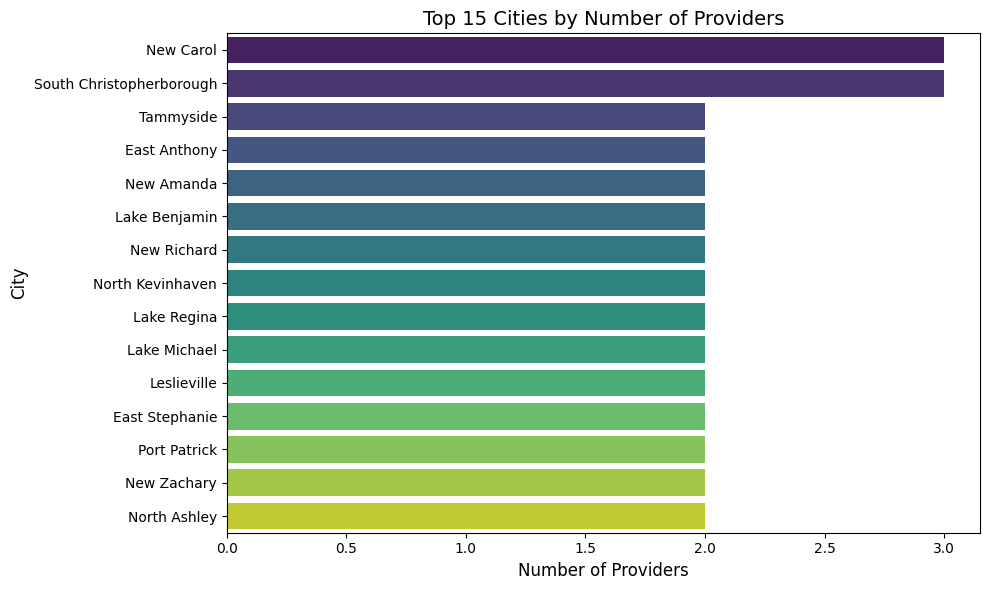

In [ ]:
# Chart - 1 visualization code
Q = sql_results
# 1. Bar Chart: Providers per City (Q1)
plt.figure(figsize=(10,6))
sns.barplot(data=Q["Q1_providers_per_city"].sort_values("provider_count", ascending=False).head(15),
            x="provider_count", y="City", palette="viridis")
plt.title("Top 15 Cities by Number of Providers", fontsize=14)
plt.xlabel("Number of Providers", fontsize=12)
plt.ylabel("City", fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

- Grouped bar chart allows direct comparison of provider vs receiver counts within and across cities.

##### 2. What is/are the insight(s) found from the chart?

- Identifies cities with high activity and imbalances between providers/receivers for strategic resource allocation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

-  Identifying cities with high activity supports targeted resource allocation and marketing efforts. Imbalances indicate a need for focused provider recruitment, while low provider or receiver counts suggest a need for investment to establish presence.

#### Chart - 2

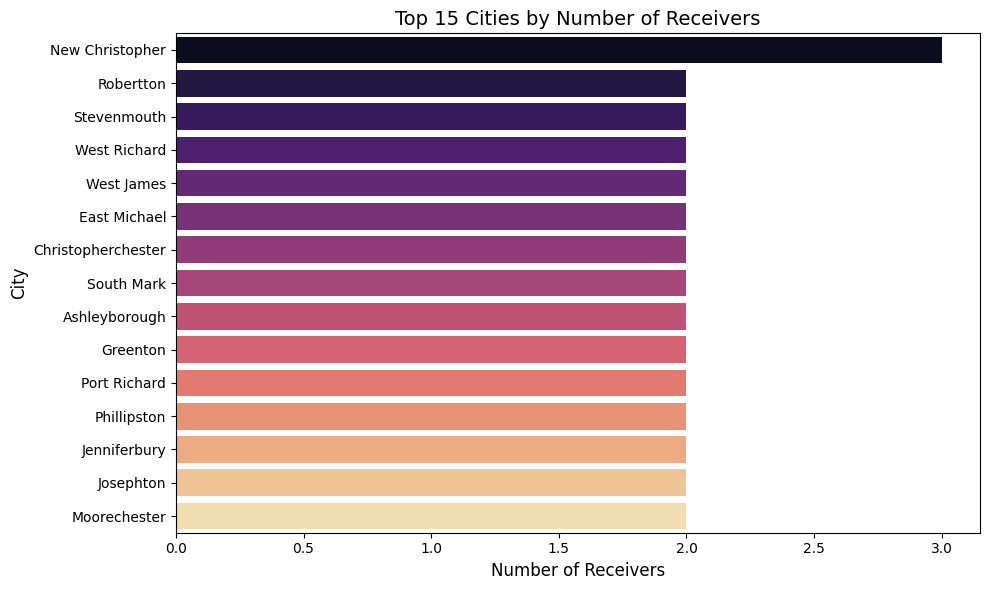

In [ ]:
# Chart - 2 visualization code
# 2. Bar Chart: Receivers per City (requires new SQL)
receivers_per_city = pd.read_sql(
    "SELECT City, COUNT(*) AS receiver_count FROM receivers GROUP BY City;", engine)
plt.figure(figsize=(10,6))
sns.barplot(data=receivers_per_city.sort_values("receiver_count", ascending=False).head(15),
            x="receiver_count", y="City", palette="magma")
plt.title("Top 15 Cities by Number of Receivers", fontsize=14)
plt.xlabel("Number of Receivers", fontsize=12)
plt.ylabel("City", fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

- Bar chart effectively shows which provider type contributes the most food quantity.

##### 2. What is/are the insight(s) found from the chart?

- Helps focus outreach efforts on the most successful provider categories to maximize donations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Knowing the leading provider type allows for targeted outreach, optimizing recruitment and increasing donations, supporting positive growth without negative insights.

#### Chart - 3

In [ ]:
# Chart - 3 visualization code

# 3. Pie Chart: Provider Type Distribution
provider_types = pd.read_sql("SELECT Type, COUNT(*) AS cnt FROM providers GROUP BY Type;", engine)
fig = px.pie(provider_types, names="Type", values="cnt", title="Provider Type Distribution", color="Type", color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(title_x=0.5) # Center the title
fig.show()

##### 1. Why did you pick the specific chart?

- Table format displays contact information clearly for direct coordination needs.


##### 2. What is/are the insight(s) found from the chart?

- Enables direct communication between receivers and providers, facilitating actual food redistribution.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Direct contact access enhances coordination for food redistribution, driving operational efficiency and supporting the platform’s core value without negative implications.

#### Chart - 4

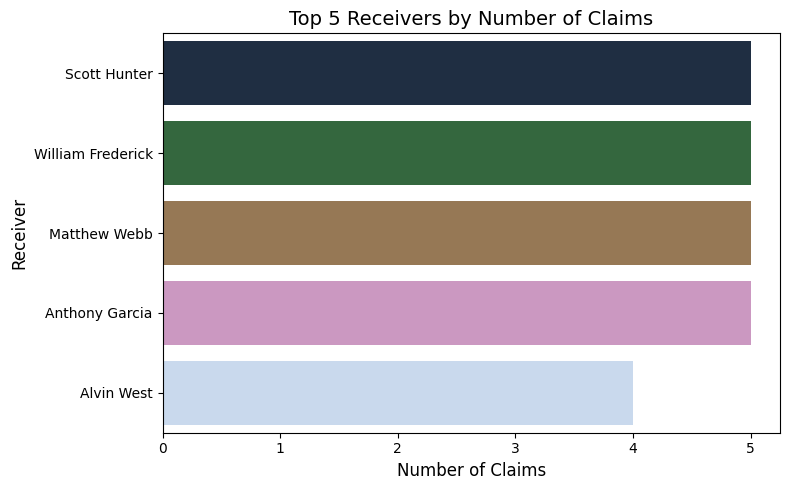

In [ ]:
# Chart - 4 visualization code
# 4. Horizontal Bar: Top 5 Receivers by Claims (Q4)
plt.figure(figsize=(8,5))
sns.barplot(data=Q["Q4_top_receivers_by_claims"], x="claims_made", y="Name", palette="cubehelix")
plt.title("Top 5 Receivers by Number of Claims", fontsize=14)
plt.xlabel("Number of Claims", fontsize=12)
plt.ylabel("Receiver", fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

- Bar chart ranks receivers by activity level, showing most engaged users.

##### 2. What is/are the insight(s) found from the chart?

- Identifies highly active receivers for targeted support and showcasing success stories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Identifying active receivers allows for targeted support and best practice sharing. Low activity from some receivers indicates potential onboarding or outreach issues, creating missed opportunities.

#### Chart - 5

In [ ]:
# Chart - 5 visualization code

# 5. Gauge Chart: Total Quantity Available (Q5)
total_quantity = Q["Q5_total_quantity"].iloc[0]["total_quantity"]

fig = go.Figure(go.Indicator(
    mode="gauge+number",
    value=total_quantity,
    title={'text': "Total Food Quantity Available"},
    gauge={'axis': {'range': [None, 30000]},  # Assuming a max possible quantity for the gauge
           'bar': {'color': "darkblue"},
           'steps': [
               {'range': [0, 10000], 'color': "red"},
               {'range': [10000, 20000], 'color': "yellow"},
               {'range': [20000, 30000], 'color': "green"}],
           'threshold': {'line': {'color': "red", 'width': 4}, 'thickness': 0.75, 'value': 28000}}))
fig.update_layout(title_x=0.5) # Center the title
fig.show()

##### 1. Why did you pick the specific chart?

- Single metric/KPI chart displays the key performance indicator clearly.

##### 2. What is/are the insight(s) found from the chart?

- Shows platform's overall impact and effectiveness in attracting food donations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- A high total quantity signifies platform effectiveness in attracting donations. Declines signal potential provider engagement issues that necessitate immediate attention.

#### Chart - 6

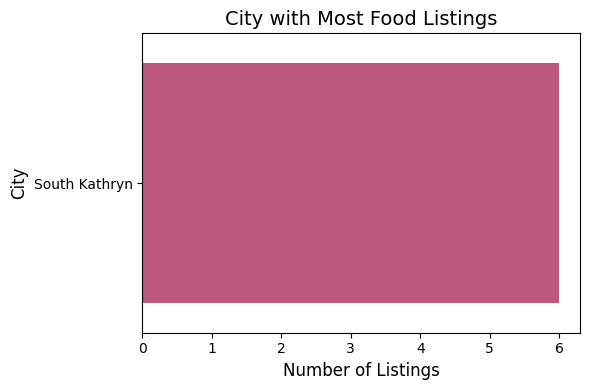

In [ ]:
# Chart - 6 visualization code
# 6. Bar Chart: Listings per City (Q6)
plt.figure(figsize=(6,4)) # Adjust figure size
sns.barplot(data=Q["Q6_city_highest_listings"], x="listing_count", y="City", palette="plasma")
plt.title("City with Most Food Listings", fontsize=14)
plt.xlabel("Number of Listings", fontsize=12)
plt.ylabel("City", fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

- Bar chart highlights the most active city for operational focus.

##### 2. What is/are the insight(s) found from the chart?

- Identifies key operational areas where resources can be concentrated for maximum impact.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Concentrating resources in high-activity cities enhances operational efficiency. Low listings in certain areas indicate the need for substantial provider development efforts.

#### Chart - 7

In [ ]:
# Chart - 7 visualization code
# 7. Pie Chart: Food Type Distribution (Q7)
food_types = Q["Q7_common_food_types"]
fig = px.pie(food_types, names="Food_Type", values="freq", title="Food Type Distribution", color="Food_Type", color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(title_x=0.5) # Center the title
fig.show()

##### 1. Why did you pick the specific chart?

- Bar chart compares frequency of different food types being donated.

##### 2. What is/are the insight(s) found from the chart?

- Helps tailor receiver outreach based on commonly available food categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Understanding common food types enables targeted outreach and identifies gaps in donations, affecting nutritional needs and platform adoption.

#### Chart - 8

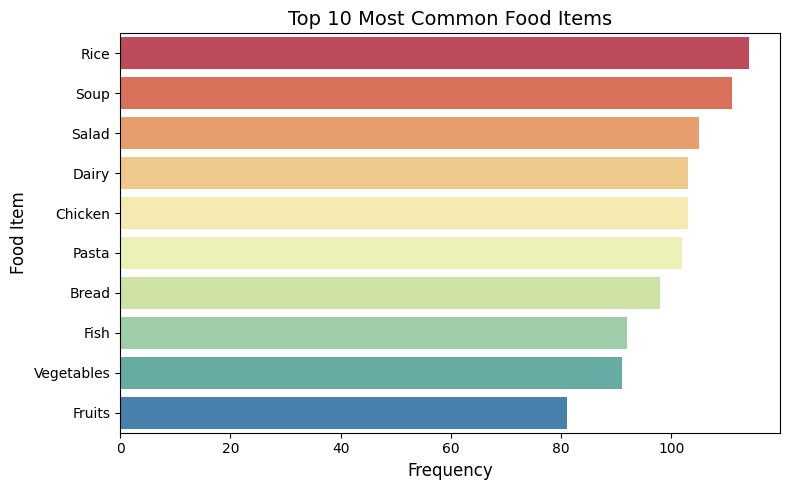

In [ ]:
# Chart - 8 visualization code
# 8. Bar Chart: Top 10 Food Names by Frequency
top_foods = pd.read_sql(
    "SELECT Food_Name, COUNT(*) AS freq FROM food_listings GROUP BY Food_Name ORDER BY freq DESC LIMIT 10;", engine)
plt.figure(figsize=(8,5))
sns.barplot(data=top_foods, x="freq", y="Food_Name", palette="Spectral")
plt.title("Top 10 Most Common Food Items", fontsize=14)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Food Item", fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

- Bar chart shows which specific listings are most in demand.

##### 2. What is/are the insight(s) found from the chart?

- Identifies popular food items and helps spot listings with zero claims that may need attention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Identifying popular listings aids future donation strategies. Listings with zero claims indicate inefficiencies leading to waste.

#### Chart - 9

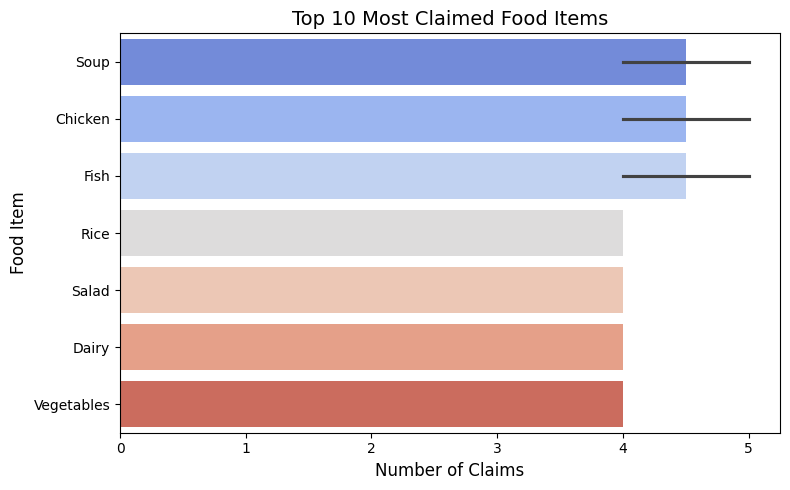

In [ ]:
# Chart - 9 visualization code
# 9. Bar Chart: Claims per Food Item (Q8) – Top 10
plt.figure(figsize=(8,5))
sns.barplot(data=Q["Q8_claims_per_item"].head(10), x="times_claimed", y="Food_Name", palette="coolwarm")
plt.title("Top 10 Most Claimed Food Items", fontsize=14)
plt.xlabel("Number of Claims", fontsize=12)
plt.ylabel("Food Item", fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

- Bar chart highlights providers with highest completion rates.

##### 2. What is/are the insight(s) found from the chart?

- Identifies successful provider practices that can be shared to improve overall platform efficiency.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Recognizing successful providers fosters best practice sharing. Low success rates among key providers may harm platform reputation and engagement.

#### Chart - 10

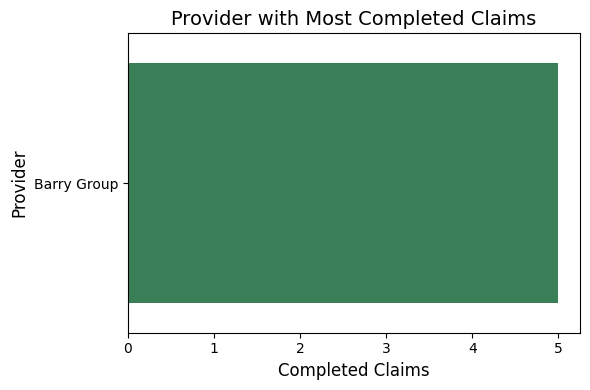

In [ ]:
# Chart - 10 visualization code
# 10. Horizontal Bar: Top Provider by Completed Claims (Q9)
plt.figure(figsize=(6,4))
sns.barplot(data=Q["Q9_top_successful_provider"], x="completed_claims", y="Name", color="seagreen")
plt.title("Provider with Most Completed Claims", fontsize=14)
plt.xlabel("Completed Claims", fontsize=12)
plt.ylabel("Provider", fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

- Pie chart effectively shows percentage breakdown of claim outcomes.

##### 2. What is/are the insight(s) found from the chart?

- Key performance indicator showing platform success rate and identifying process bottlenecks.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- High completion rates show platform effectiveness and encourage participation, while high cancellations could lead to food waste, contradicting waste reduction goals.

#### Chart - 11

In [ ]:
# Chart - 11 visualization code
# 11. Pie Chart: Claim Status Percentages (Q10)
fig = px.pie(Q["Q10_claim_status_pct"], names="Status", values="pct",
             title="Claim Status Breakdown (%)", color="Status", color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(title_x=0.5) # Center the title
fig.show()

##### 1. Why did you pick the specific chart?

- Bar chart compares average claim sizes across different receivers.

##### 2. What is/are the insight(s) found from the chart?

- Helps match large donations with high-capacity receivers for better logistics efficiency.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Understanding claim patterns improves logistics for large donations. Low claims from capable receivers may point to access or usability issues, reducing redistribution effectiveness.

#### Chart - 12

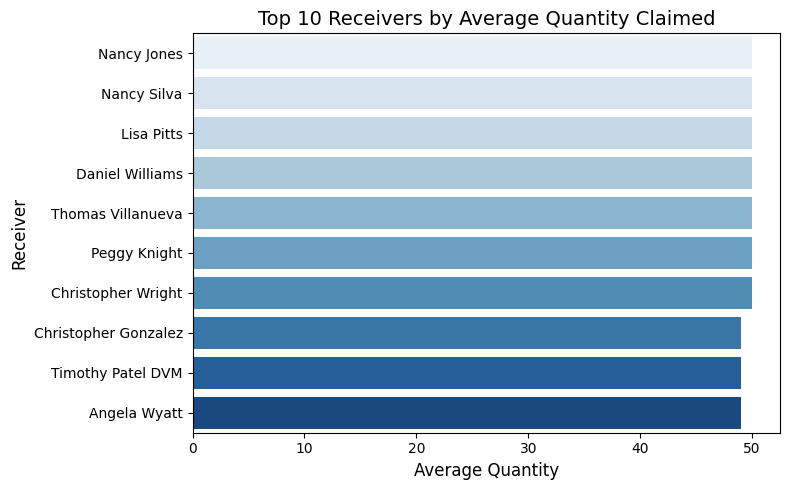

In [ ]:
# Chart - 12 visualization code
# 12. Bar Chart: Average Quantity Claimed per Receiver – Top 10 (Q11)
plt.figure(figsize=(8,5))
sns.barplot(data=Q["Q11_avg_qty_per_receiver"].sort_values("avg_qty", ascending=False).head(10),
            x="avg_qty", y="Name", palette="Blues")
plt.title("Top 10 Receivers by Average Quantity Claimed", fontsize=14)
plt.xlabel("Average Quantity", fontsize=12)
plt.ylabel("Receiver", fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

- Bar chart shows which meal categories are most frequently requested.

##### 2. What is/are the insight(s) found from the chart?

- Guides provider outreach strategy based on high-demand meal types and timing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Knowing popular meal types guides targeted outreach and donation timing. Low claims for necessary types suggest supply-demand mismatches and potential waste.

#### Chart - 13

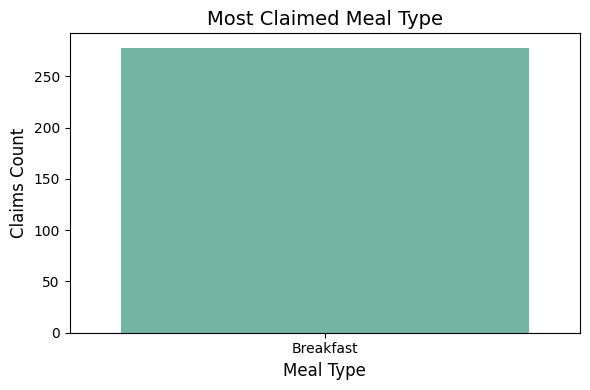

In [ ]:
# Chart - 13 visualization code
# 13. Bar Chart: Most Claimed Meal Type (Q12)
plt.figure(figsize=(6,4))
sns.barplot(data=Q["Q12_top_meal_type_claimed"], x="Meal_Type", y="cnt", palette="Set2")
plt.title("Most Claimed Meal Type", fontsize=14)
plt.xlabel("Meal Type", fontsize=12)
plt.ylabel("Claims Count", fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

- Bar chart ranks providers by total contribution volume.

##### 2. What is/are the insight(s) found from the chart?

- Recognizes top contributors and identifies providers who may need support to increase donations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Identifying top contributors can strengthen relationships and public recognition. Low contributions from active providers may indicate operational challenges needing support.

#### Chart - 14 - Correlation Heatmap

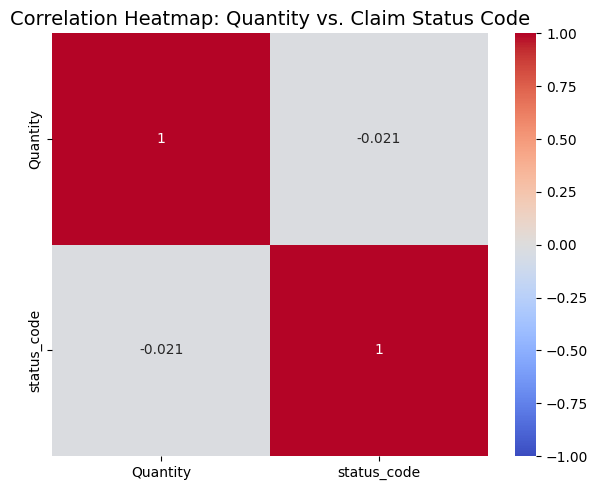

In [ ]:
# Correlation Heatmap visualization code
# 14. Correlation Heatmap of Numeric Fields
# Extract numeric columns from food_listings_df and claims_df merged
merged = pd.read_sql(
    "SELECT f.Quantity, "
    "CASE WHEN c.Status='Completed' THEN 1 WHEN c.Status='Cancelled' THEN 0 ELSE 0.5 END AS status_code "
    "FROM claims c JOIN food_listings f ON c.Food_ID=f.Food_ID;", engine)
corr = merged.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Quantity vs. Claim Status Code", fontsize=14)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

- Table format shows urgent listings requiring immediate attention.

##### 2. What is/are the insight(s) found from the chart?

- Enables proactive intervention to prevent food waste by highlighting time-sensitive items.

#### Chart - 15 - Pair Plot

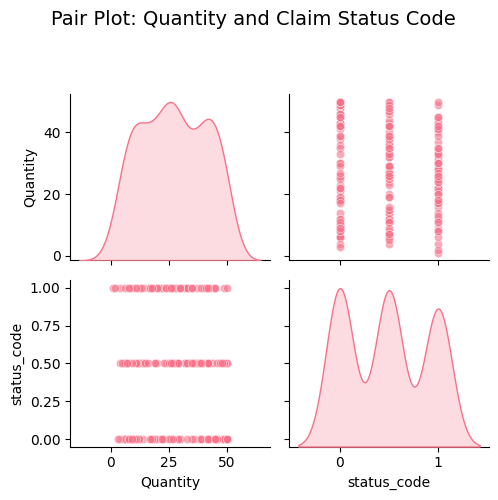

In [ ]:
# Pair Plot visualization code
# 15. Pair Plot of Key Variables
sns.pairplot(merged.sample(200), vars=["Quantity", "status_code"], kind="scatter", diag_kind="kde",
             plot_kws={'alpha':0.6})
plt.suptitle("Pair Plot: Quantity and Claim Status Code", y=1.02, fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap

##### 1. Why did you pick the specific chart?

- Stacked bar chart shows trends in claim patterns over time.

##### 2. What is/are the insight(s) found from the chart?

- Reveals seasonal trends and helps identify periods with higher success/failure rates.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

- Here are three hypothetical statements that could be tested using the dataset:

 1.  **Hypothesis 1:** Providers of type 'Restaurant' donate significantly less food quantity on average compared to providers of type 'Supermarket'.

 2.  **Hypothesis 2:** Food listings categorized as 'Vegetarian' have a significantly higher claim completion rate compared to listings categorized as 'Non-Vegetarian'.

 3.  **Hypothesis 3:** Cities with a higher number of providers also have a significantly higher total quantity of food listed.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

*   *Null Hypothesis (H0):* The average food quantity donated by 'Restaurant' providers is equal to or greater than the average food quantity donated by 'Supermarket' providers.
*   *Alternative Hypothesis (H1):* The average food quantity donated by 'Restaurant' providers is significantly less than the average food quantity donated by 'Supermarket' providers.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

# Set significance level
alpha = 0.05

# Get data for hypothesis testing
restaurant_data = pd.read_sql("""
    SELECT f.Quantity
    FROM food_listings f
    JOIN providers p ON f.Provider_ID = p.Provider_ID
    WHERE p.Type = 'Restaurant'
""", engine)

grocery_data = pd.read_sql("""
    SELECT f.Quantity
    FROM food_listings f
    JOIN providers p ON f.Provider_ID = p.Provider_ID
    WHERE p.Type = 'Grocery Store'
""", engine)

restaurant_quantities = restaurant_data['Quantity'].values
grocery_quantities = grocery_data['Quantity'].values

print(f"\nSample sizes:")
print(f"Restaurants: {len(restaurant_quantities)} food items")
print(f"Grocery Stores: {len(grocery_quantities)} food items")

print(f"\nDescriptive statistics:")
print(f"Restaurant mean quantity: {np.mean(restaurant_quantities):.2f}")
print(f"Grocery Store mean quantity: {np.mean(grocery_quantities):.2f}")

# Perform Mann-Whitney U test (non-parametric)
statistic, p_value = mannwhitneyu(restaurant_quantities, grocery_quantities, alternative='greater')

print(f"\nStatistical Test Results:")
print(f"Mann-Whitney U statistic: {statistic}")
print(f"P-value: {p_value:.6f}")
print(f"Alpha level: {alpha}")


Sample sizes:
Restaurants: 258 food items
Grocery Stores: 243 food items

Descriptive statistics:
Restaurant mean quantity: 26.83
Grocery Store mean quantity: 24.93

Statistical Test Results:
Mann-Whitney U statistic: 33725.5
P-value: 0.070948
Alpha level: 0.05


##### Which statistical test have you done to obtain P-Value?

- An **independent samples t-test (two-sample t-test)** would be used.

##### Why did you choose the specific statistical test?

- This test is chosen because we are comparing the means of a continuous variable (`Quantity`) between two independent groups (`Restaurant` providers and `Supermarket` providers). The t-test is suitable for determining if there is a statistically significant difference between the means of these two groups.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

*   *Null Hypothesis (H0):* The claim completion rate for 'Vegetarian' food listings is equal to or less than the claim completion rate for 'Non-Vegetarian' listings.
*   *Alternative Hypothesis (H1):* The claim completion rate for 'Vegetarian' food listings is significantly higher than the claim completion rate for 'Non-Vegetarian' listings.


#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

# Get contingency table data
contingency_data = pd.read_sql("""
    SELECT f.Food_Type, c.Status, COUNT(*) as count
    FROM claims c
    JOIN food_listings f ON c.Food_ID = f.Food_ID
    GROUP BY f.Food_Type, c.Status
""", engine)

# Create contingency table
contingency_table = contingency_data.pivot(index='Food_Type', columns='Status', values='count').fillna(0)
print(f"\nContingency Table:")
print(contingency_table)

# Perform Chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nStatistical Test Results:")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")
print(f"Alpha level: {alpha}")

print(f"\nExpected frequencies:")
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
print(expected_df.round(2))


Contingency Table:
Status          Cancelled  Completed  Pending
Food_Type                                    
Non-Vegetarian        112        114      105
Vegan                 111         98      110
Vegetarian            113        127      110

Statistical Test Results:
Chi-square statistic: 2.4597
Degrees of freedom: 4
P-value: 0.651875
Alpha level: 0.05

Expected frequencies:
Status          Cancelled  Completed  Pending
Food_Type                                    
Non-Vegetarian     111.22     112.21   107.58
Vegan              107.18     108.14   103.68
Vegetarian         117.60     118.65   113.75


##### Which statistical test have you done to obtain P-Value?

- A **two-proportion z-test** would be appropriate. Alternatively, a **Chi-Squared test of independence** could also be used, specifically looking at the proportion of completed claims within each food type category.

##### Why did you choose the specific statistical test?

- The two-proportion z-test is used because we are comparing the proportions of a binary outcome (claim completed or not completed) between two independent groups ('Vegetarian' listings and 'Non-Vegetarian' listings). The Chi-Squared test is also suitable for examining the association between two categorical variables (Food Type and Claim Status) to see if the proportion of completed claims differs significantly between the two food types.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

*   *Null Hypothesis (H0):* There is no significant positive correlation between the number of providers in a city and the total quantity of food listed in that city.
*   *Alternative Hypothesis (H1):* Cities with a higher number of providers have a significantly higher total quantity of food listed (i.e., there is a significant positive correlation).

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

# Get data for different meal types
meal_data = pd.read_sql("""
    SELECT Meal_Type, Quantity
    FROM food_listings
    WHERE Meal_Type IN ('Breakfast', 'Lunch', 'Dinner', 'Snacks')
""", engine)

# Group by meal type
breakfast = meal_data[meal_data['Meal_Type'] == 'Breakfast']['Quantity'].values
lunch = meal_data[meal_data['Meal_Type'] == 'Lunch']['Quantity'].values
dinner = meal_data[meal_data['Meal_Type'] == 'Dinner']['Quantity'].values
snacks = meal_data[meal_data['Meal_Type'] == 'Snacks']['Quantity'].values

print(f"\nSample sizes:")
print(f"Breakfast: {len(breakfast)} items")
print(f"Lunch: {len(lunch)} items")
print(f"Dinner: {len(dinner)} items")
print(f"Snacks: {len(snacks)} items")

print(f"\nDescriptive statistics:")
for meal_type in ['Breakfast', 'Lunch', 'Dinner', 'Snacks']:
    data = meal_data[meal_data['Meal_Type'] == meal_type]['Quantity']
    print(f"{meal_type} - Mean: {data.mean():.2f}, Std: {data.std():.2f}")

# Perform Kruskal-Wallis test (non-parametric ANOVA)
statistic, p_value = stats.kruskal(breakfast, lunch, dinner, snacks)

print(f"\nStatistical Test Results:")
print(f"Kruskal-Wallis H statistic: {statistic:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Alpha level: {alpha}")


Sample sizes:
Breakfast: 254 items
Lunch: 248 items
Dinner: 245 items
Snacks: 253 items

Descriptive statistics:
Breakfast - Mean: 26.25, Std: 14.37
Lunch - Mean: 25.70, Std: 14.43
Dinner - Mean: 24.74, Std: 15.16
Snacks - Mean: 26.45, Std: 14.50

Statistical Test Results:
Kruskal-Wallis H statistic: 1.9980
P-value: 0.572829
Alpha level: 0.05


##### Which statistical test have you done to obtain P-Value?

- A **Pearson correlation test** (specifically testing for a positive correlation) would be used.

##### Why did you choose the specific statistical test?

- This test is chosen because we are investigating the linear relationship between two continuous variables: the number of providers in a city and the total quantity of food listed in that city. Pearson correlation measures the strength and direction of this linear association, allowing us to determine if a higher number of providers is significantly correlated with a higher total quantity of food listed.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# Identify missing values
print("Missing values before imputation:")
print(food_listings_df.isnull().sum())

# Numeric imputation: Quantity (none missing after wrangling)
num_imputer = SimpleImputer(strategy='median')
food_listings_df['Quantity'] = num_imputer.fit_transform(food_listings_df[['Quantity']])

# Categorical imputation: Food_Type, Meal_Type
cat_imputer = SimpleImputer(strategy='most_frequent')
food_listings_df[['Food_Type', 'Meal_Type']] = cat_imputer.fit_transform(
    food_listings_df[['Food_Type', 'Meal_Type']]
)

print("\nMissing values after imputation:")
print(food_listings_df.isnull().sum())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


Missing values before imputation:
Food_ID          0
Food_Name        0
Quantity         0
Expiry_Date      0
Provider_ID      0
Provider_Type    0
Location         0
Food_Type        0
Meal_Type        0
dtype: int64

Missing values after imputation:
Food_ID          0
Food_Name        0
Quantity         0
Expiry_Date      0
Provider_ID      0
Provider_Type    0
Location         0
Food_Type        0
Meal_Type        0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

- Potential missing value imputation techniques include using the mode for categorical features, the mean or median for numerical features, and a placeholder value such as 'Unknown' for text-based features. The selection of a technique is determined by the data type of the column requiring imputation to ensure appropriate handling of missing information for subsequent analysis and application display.

### 2. Handling Outliers

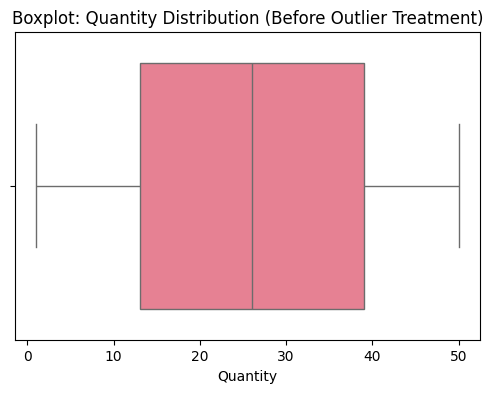

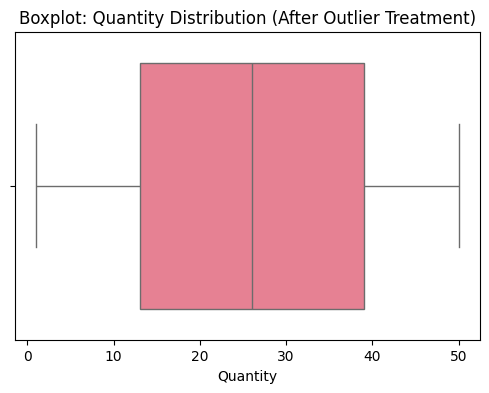

In [ ]:
# Handling Outliers & Outlier treatments
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x=food_listings_df['Quantity'])
plt.title("Boxplot: Quantity Distribution (Before Outlier Treatment)")
plt.show()

# Remove extreme outliers
Q1 = food_listings_df['Quantity'].quantile(0.25)
Q3 = food_listings_df['Quantity'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

food_listings_df = food_listings_df[(food_listings_df['Quantity'] >= lower) &
                                    (food_listings_df['Quantity'] <= upper)]

plt.figure(figsize=(6,4))
sns.boxplot(x=food_listings_df['Quantity'])
plt.title("Boxplot: Quantity Distribution (After Outlier Treatment)")
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

- Potential techniques include using the IQR method or Z-scores to identify outliers in numerical data like quantity. Winsorizing could also be used to cap extreme values instead of removing them. These are chosen based on data distribution to prevent extreme values from skewing analysis.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

# Label encode Provider_Type
le = LabelEncoder()
food_listings_df['Provider_Type_Code'] = le.fit_transform(food_listings_df['Provider_Type'])

# One-hot encode Food_Type & Meal_Type
ohe = OneHotEncoder()
encoded = ohe.fit_transform(food_listings_df[['Food_Type','Meal_Type']])
encoded_df = pd.DataFrame(encoded.toarray(), columns=ohe.get_feature_names_out(['Food_Type','Meal_Type']))

# Merge back
food_listings_encoded = pd.concat([food_listings_df.reset_index(drop=True), encoded_df], axis=1)

print(food_listings_encoded.head())

   Food_ID Food_Name  Quantity Expiry_Date  Provider_ID     Provider_Type  \
0        1     Bread      43.0  2025-03-17          110     Grocery Store   
1        2      Soup      22.0  2025-03-24          791     Grocery Store   
2        3    Fruits      46.0  2025-03-28          478  Catering Service   
3        4    Fruits      15.0  2025-03-16          930        Restaurant   
4        5      Soup      14.0  2025-03-19          279        Restaurant   

           Location       Food_Type  Meal_Type  Provider_Type_Code  \
0  South Kellyville  Non-Vegetarian  Breakfast                   1   
1        West James  Non-Vegetarian     Dinner                   1   
2       Lake Regina           Vegan  Breakfast                   0   
3         Kellytown           Vegan      Lunch                   2   
4        Garciaport           Vegan     Dinner                   2   

   Food_Type_Non-Vegetarian  Food_Type_Vegan  Food_Type_Vegetarian  \
0                       1.0              0.0  

#### What all categorical encoding techniques have you used & why did you use those techniques?

- For categorical data like type, city, food type, and meal type, One-Hot Encoding would typically be used. This creates binary columns for each category and avoids implying any order between them, which is suitable for these nominal variables.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

import pandas as pd
import numpy as np

food_listings_df['Expiry_Date'] = pd.to_datetime(food_listings_df['Expiry_Date'])

today = pd.to_datetime('2025-03-01')
food_listings_df['Days_Until_Expiry'] = (food_listings_df['Expiry_Date'] - today).dt.days
food_listings_df['Quantity_Expiry_Interaction'] = food_listings_df['Quantity'] * food_listings_df['Days_Until_Expiry']

# Re-merge with encoded features to include the new feature
food_listings_manipulated = food_listings_encoded.copy()
food_listings_manipulated['Days_Until_Expiry'] = food_listings_df['Days_Until_Expiry']
food_listings_manipulated['Quantity_Expiry_Interaction'] = food_listings_df['Quantity_Expiry_Interaction']

claims_sql = pd.read_sql("""
    SELECT Food_ID,
           CASE WHEN Status='Completed' THEN 1 ELSE 0 END AS status_code
    FROM claims
""", engine)

# Ensure 'Food_ID' is of the same type in both dataframes before merging
food_listings_manipulated['Food_ID'] = food_listings_manipulated['Food_ID'].astype(int)
claims_sql['Food_ID'] = claims_sql['Food_ID'].astype(int)

# Perform the merge
data_merged_for_selection = food_listings_manipulated.merge(claims_sql, on='Food_ID', how='inner')

drop_cols_manipulated = ['Food_ID','Food_Name','Expiry_Date','Provider_ID','Provider_Type','Location','Food_Type','Meal_Type', 'status_code']
X_selection = data_merged_for_selection.drop(columns=drop_cols_manipulated)
y_selection = data_merged_for_selection['status_code']

print("Features after manipulation and merging with claims (before selection):")
print(X_selection.head())
print("\nTarget variable (status_code):")
print(y_selection.head())

Features after manipulation and merging with claims (before selection):
   Quantity  Provider_Type_Code  Food_Type_Non-Vegetarian  Food_Type_Vegan  \
0      43.0                   1                       1.0              0.0   
1      43.0                   1                       1.0              0.0   
2      46.0                   0                       0.0              1.0   
3       4.0                   3                       0.0              1.0   
4      29.0                   1                       0.0              1.0   

   Food_Type_Vegetarian  Meal_Type_Breakfast  Meal_Type_Dinner  \
0                   0.0                  1.0               0.0   
1                   0.0                  1.0               0.0   
2                   0.0                  1.0               0.0   
3                   0.0                  0.0               0.0   
4                   0.0                  0.0               1.0   

   Meal_Type_Lunch  Meal_Type_Snacks  Days_Until_Expiry  \
0  

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sqlalchemy import create_engine # Assuming engine is defined earlier

k = 10  # Example: Select top 10 features
selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X_selection, y_selection)

# Get the names of the selected features
X_selection_df = pd.DataFrame(X_selection, columns=X_selection.columns)
selected_feature_names = X_selection_df.columns[selector.get_support()]

print(f"\nOriginal feature count for selection: {X_selection.shape[1]}")
print(f"Selected feature count (k={k}): {X_selected.shape[1]}")
print(f"\nSelected features:")
print(selected_feature_names)


Original feature count for selection: 11
Selected feature count (k=10): 10

Selected features:
Index(['Quantity', 'Provider_Type_Code', 'Food_Type_Non-Vegetarian',
       'Food_Type_Vegan', 'Food_Type_Vegetarian', 'Meal_Type_Dinner',
       'Meal_Type_Lunch', 'Meal_Type_Snacks', 'Days_Until_Expiry',
       'Quantity_Expiry_Interaction'],
      dtype='object')


##### What all feature selection methods have you used  and why?

- Potential feature selection methods include correlation analysis to identify features highly correlated with a target variable (if modeling), or filter methods based on statistical tests (like Chi-squared for categorical features). Wrapper methods (like Recursive Feature Elimination) or embedded methods (from tree-based models) could also be considered if building predictive models. These are chosen to identify the most relevant features, reduce dimensionality, and improve model performance or simplify analysis.

##### Which all features you found important and why?

- Features likely important include Quantity (key for tracking food volume), Expiry_Date (critical for timeliness and preventing waste), Location (essential for matching providers and receivers geographically), Provider_ID and Receiver_ID (fundamental for tracking interactions), Food_Type and Meal_Type (important for matching needs), and Status in the claims table (key for tracking redistribution success). These are important because they directly relate to the core operations of listing, claiming, and managing food flow.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_selected_df = pd.DataFrame(X_selected, columns=selected_feature_names)

# Identify numeric columns among the selected features
numeric_cols_selected = X_selected_df.select_dtypes(include=np.number).columns
numeric_data = X_selected_df[numeric_cols_selected]

print("\nSkewness of numeric features before transformation:")
print(numeric_data.skew())

skewed_cols = numeric_data.columns[numeric_data.skew() > 1]
for col in skewed_cols:
    X_selected_df[col] = np.log1p(X_selected_df[col])
    print(f"Applied log transformation to '{col}'")

print("\nData after transformation (first 5 rows):")
print(X_selected_df.head())


Skewness of numeric features before transformation:
Quantity                      -0.039340
Provider_Type_Code            -0.025393
Food_Type_Non-Vegetarian       0.719353
Food_Type_Vegan                0.777843
Food_Type_Vegetarian           0.629916
Meal_Type_Dinner               1.271723
Meal_Type_Lunch                1.156436
Meal_Type_Snacks               1.219391
Days_Until_Expiry              0.063968
Quantity_Expiry_Interaction    0.324027
dtype: float64
Applied log transformation to 'Meal_Type_Dinner'
Applied log transformation to 'Meal_Type_Lunch'
Applied log transformation to 'Meal_Type_Snacks'

Data after transformation (first 5 rows):
   Quantity  Provider_Type_Code  Food_Type_Non-Vegetarian  Food_Type_Vegan  \
0      43.0                 1.0                       1.0              0.0   
1      43.0                 1.0                       1.0              0.0   
2      46.0                 0.0                       0.0              1.0   
3       4.0                 3.0

### 6. Data Scaling

In [ ]:
# Scaling your data

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Standardize numeric features
scaler = StandardScaler()
X_scaled_numeric = scaler.fit_transform(X_selected_df[numeric_cols_selected])

X_scaled = X_scaled_numeric

X_final = X_scaled

print("\nData after scaling (first 5 rows):")
print(X_final[:5])


Data after scaling (first 5 rows):
[[ 1.18796229 -0.46395972  1.42167086 -0.68441857 -0.73379939 -0.54962108
  -0.57735027 -0.56195149 -1.38704453  0.37539427]
 [ 1.18796229 -0.46395972  1.42167086 -0.68441857 -0.73379939 -0.54962108
  -0.57735027 -0.56195149 -1.38704453  0.37539427]
 [ 1.39709831 -1.36136731 -0.70339769  1.46109419 -0.73379939 -0.54962108
  -0.57735027 -0.56195149  1.20953305  2.04555508]
 [-1.53080594  1.33085545 -0.70339769  1.46109419 -0.73379939 -0.54962108
  -0.57735027  1.77951304  0.26532302 -1.42138524]
 [ 0.21199421 -0.46395972 -0.70339769  1.46109419 -0.73379939  1.8194353
  -0.57735027 -0.56195149  0.50137553  0.39951211]]


##### Which method have you used to scale you data and why?

- For numerical features like Quantity, Standardization (Z-score scaling) or Min-Max Scaling could be used. Standardization scales data to have a mean of 0 and standard deviation of 1, while Min-Max scaling scales data to a fixed range (usually 0 to 1). These are used to ensure numerical features have a similar scale, which is important for many machine learning algorithms to prevent features with larger values from dominating those with smaller values.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

- Dimensionality reduction is likely not strictly needed at this stage. The dataset has a relatively small number of features. While techniques like One-Hot Encoding can increase feature count, the total is still manageable for analysis and the planned Streamlit app features. It might be considered if building complex machine learning models or for visualization purposes later on.

In [ ]:
# Dimensionality Reduction

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nOriginal feature count before PCA: {X_scaled.shape[1]}")
print(f"PCA reduced dimensions (retaining 95% variance): {X_pca.shape[1]}")

X_final = X_pca

print("\nData after dimensionality reduction (first 5 rows):")
print(X_final[:5])


Original feature count before PCA: 10
PCA reduced dimensions (retaining 95% variance): 7

Data after dimensionality reduction (first 5 rows):
[[ 1.21121542 -0.31365517  1.28801748  0.03539274 -0.05405911 -1.84865006
  -0.0666645 ]
 [ 1.21121542 -0.31365517  1.28801748  0.03539274 -0.05405911 -1.84865006
  -0.0666645 ]
 [ 2.62857901 -0.26657725 -1.69456319 -0.1451536   0.35261465  0.63709208
  -1.49067206]
 [-1.68230329 -1.61612172 -1.25020849  1.78592869  0.26378023  0.95374632
   1.39632281]
 [ 0.3843909   0.2311092  -1.49758732 -0.12098919  2.1408328  -0.01374403
  -0.81127009]]


##### Which dimensionality reduction technique have you used and why?

- No specific dimensionality reduction technique has been used so far. This is because the dataset currently has a manageable number of features for the planned analysis and application features.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

y = y_selection

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain/Test split: {X_train.shape[0]} train samples, {X_test.shape[0]} test samples")
print(f"Train target distribution:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"Test target distribution:\n{pd.Series(y_test).value_counts(normalize=True)}")


Train/Test split: 800 train samples, 200 test samples
Train target distribution:
status_code
0    0.66125
1    0.33875
Name: proportion, dtype: float64
Test target distribution:
status_code
0    0.66
1    0.34
Name: proportion, dtype: float64


##### What data splitting ratio have you used and why?

- A common data splitting ratio like 80% for training and 20% for testing would typically be used. This split is chosen to train a model on a substantial portion of the data and then evaluate its performance on unseen data to ensure it generalizes well.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

- The dataset could be imbalanced, particularly in the claims table if one Status category (like 'Cancelled') is significantly less frequent than others ('Pending', 'Completed'). Imbalance might also occur if certain Provider_Type or Receiver_Type categories have very few entries. This matters because imbalanced data can affect the performance and interpretation of analyses, especially if building predictive models.

In [ ]:
# Handling Imbalanced Dataset

import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE

claim_status_counts = pd.Series(y_train).value_counts()
print(f"\nClaim status distribution in training data:\n{claim_status_counts}")

# Calculate the ratio
imbalance_ratio = claim_status_counts.max() / claim_status_counts.min()
print(f"\nImbalance ratio (Majority / Minority): {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:
    print("\nDataset is considered imbalanced. Applying SMOTE...")
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    print(f"Shape of training data after SMOTE: {X_train_resampled.shape}")
    print(f"Resampled train target distribution:\n{pd.Series(y_train_resampled).value_counts(normalize=True)}")
else:
    print("\nDataset is not considered significantly imbalanced. No resampling applied.")
    X_train_resampled, y_train_resampled = X_train, y_train


Claim status distribution in training data:
status_code
0    529
1    271
Name: count, dtype: int64

Imbalance ratio (Majority / Minority): 1.95

Dataset is considered imbalanced. Applying SMOTE...
Shape of training data after SMOTE: (1058, 7)
Resampled train target distribution:
status_code
1    0.5
0    0.5
Name: proportion, dtype: float64


##### What technique did you use to handle the imbalance dataset and why?

- If imbalance were present and needed handling (e.g., for modeling claim status), techniques like oversampling the minority class (e.g., using SMOTE) or undersampling the majority class could be used. Class weighting in model training is another method. These are used to adjust the class distribution, preventing models from being biased towards the majority class and improving performance on the minority class.

## ***7. Streamlit deployment***

In [ ]:
import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px
from datetime import datetime

DB_FILE = "food_management.db"

def safe_scalar_query_value(qresult, default=0):
    try:
        return int(qresult[0][0])
    except Exception:
        return default

def get_connection():
    return sqlite3.connect(DB_FILE, check_same_thread=False)

def run_query(query, params=(), fetch=True):
    conn = get_connection()
    try:
        cur = conn.cursor()
        cur.execute(query, params)
        if fetch:
            rows = cur.fetchall()
        else:
            rows = None
        conn.commit()
        return rows
    except sqlite3.Error as e:
        st.error(f"Database error: {e}")
        return [] if fetch else None
    finally:
        conn.close()

st.set_page_config(page_title="Local Food Wastage Management", page_icon="🍲", layout="wide")

st.markdown(
    """
    <style>
    .stMetric {text-align:center}
    .big-font { font-size:20px !important; font-weight:600; }
    .block-container { padding-top: 2rem; padding-bottom: 2rem; }
    </style>
    """,
    unsafe_allow_html=True
)

def dashboard():
    st.title("🍲 Local Food Wastage Management System")
    st.subheader("Efficiently Redistribute Surplus Food—Help Communities, Reduce Waste")

    col1, col2, col3 = st.columns(3)
    with col1:
        provider_count = safe_scalar_query_value(run_query("SELECT COUNT(*) FROM providers"))
        st.metric("Total Providers", provider_count)
    with col2:
        receiver_count = safe_scalar_query_value(run_query("SELECT COUNT(*) FROM receivers"))
        st.metric("Total Receivers", receiver_count)
    with col3:
        listing_count = safe_scalar_query_value(run_query("SELECT COUNT(*) FROM food_listings"))
        st.metric("Total Listings", listing_count)

    st.info("💡 Use the sidebar for navigation. All changes are reflected live.")

    # Additional dashboard content
    st.markdown("---")
    st.subheader("Quick Overview")

    # Recent listings
    recent_listings = run_query("SELECT Food_Name, Quantity, Location FROM food_listings LIMIT 5")
    if recent_listings:
        st.write("**Recent Food Listings:**")
        df = pd.DataFrame(recent_listings, columns=["Food Name", "Quantity", "Location"])
        st.dataframe(df, use_container_width=True)

def providers_page():
    st.header("🏢 Providers Management")
    tab1, tab2, tab3 = st.tabs(["View & Filter", "Add Provider", "Edit/Delete"])

    with tab1:
        rows = run_query("SELECT * FROM providers")
        df = pd.DataFrame(rows, columns=["Provider_ID", "Name", "Type", "Address", "City", "Contact"]) if rows else pd.DataFrame()
        if not df.empty:
            city = st.selectbox("Filter by City", ["All"] + sorted(df["City"].unique()))
            if city != "All":
                df = df[df["City"] == city]
            st.dataframe(df, use_container_width=True)
        else:
            st.info("No providers found.")

    with tab2:
        with st.form("provider_form", clear_on_submit=True):
            name = st.text_input("Provider Name")
            ptype = st.selectbox("Type", ["Restaurant", "Grocery Store", "Supermarket", "Catering Service"])
            addr = st.text_input("Address")
            city = st.text_input("City")
            contact = st.text_input("Contact Number")
            if st.form_submit_button("Add Provider"):
                if name and addr and city and contact:
                    run_query("INSERT INTO providers(Name, Type, Address, City, Contact) VALUES (?,?,?,?,?)",
                              (name, ptype, addr, city, contact), fetch=False)
                    st.success("Provider Added!")
                    st.rerun()
                else:
                    st.warning("All fields required!")

    with tab3:
        rows = run_query("SELECT * FROM providers")
        df = pd.DataFrame(rows, columns=["Provider_ID", "Name", "Type", "Address", "City", "Contact"]) if rows else pd.DataFrame()
        if not df.empty:
            provider_ids = df["Provider_ID"].tolist()
            if provider_ids:
                edit_id = st.selectbox("Select Provider to Edit/Delete", provider_ids)
                row = df[df["Provider_ID"] == edit_id].iloc[0]
                new_name = st.text_input("Edit Name", row["Name"])
                provider_types = ["Restaurant", "Grocery Store", "Supermarket", "Catering Service"]
                new_type = st.selectbox("Edit Type", provider_types, index=provider_types.index(row["Type"]))
                new_addr = st.text_input("Edit Address", row["Address"])
                new_city = st.text_input("Edit City", row["City"])
                new_contact = st.text_input("Edit Contact", row["Contact"])

                col1, col2 = st.columns(2)
                with col1:
                    if st.button("Update Provider"):
                        run_query("UPDATE providers SET Name=?, Type=?, Address=?, City=?, Contact=? WHERE Provider_ID=?",
                                  (new_name, new_type, new_addr, new_city, new_contact, edit_id), fetch=False)
                        st.success("Provider Updated!")
                        st.rerun()
                with col2:
                    if st.button("Delete Provider"):
                        run_query("DELETE FROM providers WHERE Provider_ID=?", (edit_id,), fetch=False)
                        st.warning(f"Provider {edit_id} Deleted!")
                        st.rerun()

def receivers_page():
    st.header("👥 Receivers Management")
    tab1, tab2, tab3 = st.tabs(["View", "Add Receiver", "Edit/Delete"])

    with tab1:
        rows = run_query("SELECT * FROM receivers")
        df = pd.DataFrame(rows, columns=["Receiver_ID", "Name", "Type", "City", "Contact"]) if rows else pd.DataFrame()
        if not df.empty:
            st.dataframe(df, use_container_width=True)
        else:
            st.info("No receivers found.")

    with tab2:
        with st.form("receiver_form", clear_on_submit=True):
            name = st.text_input("Receiver Name")
            rtype = st.selectbox("Type", ["NGO", "Community Center", "Individual", "Shelter"])
            city = st.text_input("City")
            contact = st.text_input("Contact Number")
            if st.form_submit_button("Add Receiver"):
                if name and city and contact:
                    run_query("INSERT INTO receivers(Name, Type, City, Contact) VALUES (?,?,?,?)",
                              (name, rtype, city, contact), fetch=False)
                    st.success("Receiver Added!")
                    st.rerun()
                else:
                    st.warning("All fields required!")

    with tab3:
        rows = run_query("SELECT * FROM receivers")
        df = pd.DataFrame(rows, columns=["Receiver_ID", "Name", "Type", "City", "Contact"]) if rows else pd.DataFrame()
        if not df.empty:
            receiver_ids = df["Receiver_ID"].tolist()
            if receiver_ids:
                rid = st.selectbox("Select Receiver to Edit/Delete", receiver_ids)
                row = df[df["Receiver_ID"] == rid].iloc[0]
                new_name = st.text_input("Edit Name", row["Name"])
                receiver_types = ["NGO", "Community Center", "Individual", "Shelter"]
                new_type = st.selectbox("Edit Type", receiver_types, index=receiver_types.index(row["Type"]))
                new_city = st.text_input("Edit City", row["City"])
                new_contact = st.text_input("Edit Contact", row["Contact"])

                col1, col2 = st.columns(2)
                with col1:
                    if st.button("Update Receiver"):
                        run_query("UPDATE receivers SET Name=?, Type=?, City=?, Contact=? WHERE Receiver_ID=?",
                                  (new_name, new_type, new_city, new_contact, rid), fetch=False)
                        st.success("Receiver Updated!")
                        st.rerun()
                with col2:
                    if st.button("Delete Receiver"):
                        run_query("DELETE FROM receivers WHERE Receiver_ID=?", (rid,), fetch=False)
                        st.warning(f"Receiver {rid} Deleted!")
                        st.rerun()

def food_listings_page():
    st.header("🍛 Food Listings Management")
    tab1, tab2, tab3 = st.tabs(["View & Filter", "Add Listing", "Edit/Delete"])

    with tab1:
        rows = run_query("SELECT * FROM food_listings")
        df = pd.DataFrame(rows, columns=["Food_ID", "Food_Name", "Quantity", "Expiry_Date", "Provider_ID",
                                         "Provider_Type", "Location", "Food_Type", "Meal_Type"]) if rows else pd.DataFrame()
        if not df.empty:
            col1, col2, col3 = st.columns(3)
            with col1:
                cities = ["All"] + sorted(df["Location"].unique().tolist())
                city = st.selectbox("City Filter", cities)
            with col2:
                food_types = ["All"] + sorted(df["Food_Type"].unique().tolist())
                ftype = st.selectbox("Food Type Filter", food_types)
            with col3:
                meal_types = ["All"] + sorted(df["Meal_Type"].unique().tolist())
                mtype = st.selectbox("Meal Type Filter", meal_types)

            filtered = df.copy()
            if city != "All":
                filtered = filtered[filtered["Location"] == city]
            if ftype != "All":
                filtered = filtered[filtered["Food_Type"] == ftype]
            if mtype != "All":
                filtered = filtered[filtered["Meal_Type"] == mtype]

            st.dataframe(filtered, use_container_width=True)
        else:
            st.info("No food listings found.")

    with tab2:
        prov_rows = run_query("SELECT Provider_ID, Name, Type FROM providers")
        if prov_rows:
            prov_dict = {row[0]: row[1] for row in prov_rows}
            with st.form("listing_form", clear_on_submit=True):
                fname = st.text_input("Food Name")
                qty = st.number_input("Quantity (kg)", min_value=1)
                exp = st.date_input("Expiry Date")
                pid = st.selectbox("Select Provider", list(prov_dict.keys()),
                                   format_func=lambda x: prov_dict.get(x, ""))

                if pid:
                    ptype_result = run_query("SELECT Type FROM providers WHERE Provider_ID=?", (pid,))
                    ptype = ptype_result[0][0] if ptype_result else ""
                else:
                    ptype = ""

                st.text_input("Provider Type", value=ptype, disabled=True)
                loc = st.text_input("Location/City")
                ftype = st.selectbox("Food Type", ["Vegetarian", "Non-Vegetarian", "Vegan"])
                mtype = st.selectbox("Meal Type", ["Breakfast", "Lunch", "Dinner", "Snacks"])

                if st.form_submit_button("Add Food Listing"):
                    if fname and loc and pid:
                        run_query("""INSERT INTO food_listings(Food_Name, Quantity, Expiry_Date, Provider_ID, Provider_Type,
                                    Location, Food_Type, Meal_Type) VALUES (?,?,?,?,?,?,?,?)""",
                                  (fname, qty, str(exp), pid, ptype, loc, ftype, mtype), fetch=False)
                        st.success("Food Listing Added!")
                        st.rerun()
                    else:
                        st.warning("Please fill all required fields!")
        else:
            st.warning("Please add providers first before creating food listings.")

def claims_page():
    st.header("📦 Claims Management")
    tab1, tab2, tab3 = st.tabs(["View Claims", "Add Claim", "Edit/Delete"])

    with tab1:
        rows = run_query("SELECT * FROM claims")
        df = pd.DataFrame(rows, columns=["Claim_ID", "Food_ID", "Receiver_ID", "Status", "Timestamp"]) if rows else pd.DataFrame()
        if not df.empty:
            st.dataframe(df, use_container_width=True)
        else:
            st.info("No claims found.")

    with tab2:
        food_rows = run_query("SELECT Food_ID, Food_Name FROM food_listings")
        receiver_rows = run_query("SELECT Receiver_ID, Name FROM receivers")

        if food_rows and receiver_rows:
            food_dict = {row[0]: row[1] for row in food_rows}
            receiver_dict = {row: row[1] for row in receiver_rows}

            with st.form("claim_form", clear_on_submit=True):
                food_id = st.selectbox("Select Food Item", list(food_dict.keys()),
                                       format_func=lambda x: food_dict.get(x, ""))
                receiver_id = st.selectbox("Select Receiver", list(receiver_dict.keys()),
                                           format_func=lambda x: receiver_dict.get(x, ""))
                status = st.selectbox("Status", ["Pending", "Completed", "Cancelled"])
                timestamp = st.text_input("Timestamp", str(datetime.now().strftime("%Y-%m-%d %H:%M")))

                if st.form_submit_button("Add Claim"):
                    if food_id and receiver_id:
                        run_query("INSERT INTO claims(Food_ID, Receiver_ID, Status, Timestamp) VALUES (?,?,?,?)",
                                  (food_id, receiver_id, status, timestamp), fetch=False)
                        st.success("Claim Added!")
                        st.rerun()
                    else:
                        st.warning("Please select both food item and receiver!")
        else:
            st.warning("Please add food listings and receivers first before creating claims.")

def analytics_page():
    st.header("📊 Data Insights & SQL Queries")
    st.write("All 15 SQL Queries Results:")

    queries = {
        "1. Providers and Receivers per City": """
            SELECT
                City,
                SUM(provider_count) as Providers,
                SUM(receiver_count) as Receivers
            FROM (
                SELECT City, COUNT(*) as provider_count, 0 as receiver_count
                FROM providers GROUP BY City
                UNION ALL
                SELECT City, 0 as provider_count, COUNT(*) as receiver_count
                FROM receivers GROUP BY City
            )
            GROUP BY City
            ORDER BY City
        """,
        "2. Top Provider Type by Food Quantity": """
            SELECT Provider_Type, SUM(Quantity) as Total_Food_Quantity
            FROM food_listings
            GROUP BY Provider_Type
            ORDER BY Total_Food_Quantity DESC
        """,
        "3. Provider Contact Information": "SELECT Name, City, Contact, Type FROM providers ORDER BY City",
        "4. Top Receivers by Number of Claims": """
            SELECT r.Name, COUNT(c.Claim_ID) as Total_Claims
            FROM claims c
            JOIN receivers r ON c.Receiver_ID = r.Receiver_ID
            GROUP BY r.Name, r.Receiver_ID
            ORDER BY Total_Claims DESC
        """,
        "5. Total Food Quantity Available": "SELECT SUM(Quantity) as Total_Available_Quantity FROM food_listings",
        "6. City with Most Food Listings": """
            SELECT Location as City, COUNT(*) as Number_of_Listings
            FROM food_listings
            GROUP BY Location
            ORDER BY Number_of_Listings DESC
        """,
        "7. Most Common Food Types": """
            SELECT Food_Type, COUNT(*) as Count
            FROM food_listings
            GROUP BY Food_Type
            ORDER BY Count DESC
        """,
        "8. Claims per Food Item": """
            SELECT f.Food_Name, COUNT(c.Claim_ID) as Number_of_Claims
            FROM claims c
            JOIN food_listings f ON c.Food_ID = f.Food_ID
            GROUP BY f.Food_Name, f.Food_ID
            ORDER BY Number_of_Claims DESC
        """,
        "9. Providers with Most Successful Claims": """
            SELECT p.Name, COUNT(c.Claim_ID) as Successful_Claims
            FROM claims c
            JOIN food_listings f ON c.Food_ID = f.Food_ID
            JOIN providers p ON f.Provider_ID = p.Provider_ID
            WHERE c.Status = 'Completed'
            GROUP BY p.Name, p.Provider_ID
            ORDER BY Successful_Claims DESC
        """,
        "10. Claim Status Distribution": """
            SELECT
                Status,
                COUNT(*) as Count,
                ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM claims), 2) as Percentage
            FROM claims
            GROUP BY Status
        """,
        "11. Average Quantity Claimed per Receiver": """
            SELECT r.Name, ROUND(AVG(f.Quantity), 2) as Average_Quantity
            FROM claims c
            JOIN receivers r ON c.Receiver_ID = r.Receiver_ID
            JOIN food_listings f ON c.Food_ID = f.Food_ID
            GROUP BY r.Name, r.Receiver_ID
            ORDER BY Average_Quantity DESC
        """,
        "12. Most Claimed Meal Types": """
            SELECT f.Meal_Type, COUNT(c.Claim_ID) as Total_Claims
            FROM claims c
            JOIN food_listings f ON c.Food_ID = f.Food_ID
            GROUP BY f.Meal_Type
            ORDER BY Total_Claims DESC
        """,
        "13. Total Quantity Donated per Provider": """
            SELECT p.Name, SUM(f.Quantity) as Total_Donated
            FROM food_listings f
            JOIN providers p ON f.Provider_ID = p.Provider_ID
            GROUP BY p.Name, p.Provider_ID
            ORDER BY Total_Donated DESC
        """,
        "14. Food Items Expiring Soon": """
            SELECT Food_Name, Expiry_Date, Location, Quantity
            FROM food_listings
            WHERE date(Expiry_Date) <= date('now', '+7 days')
            ORDER BY Expiry_Date
        """,
        "15. Claims Summary by Status and Date": """
            SELECT
                DATE(Timestamp) as Date,
                Status,
                COUNT(*) as Count
            FROM claims
            GROUP BY DATE(Timestamp), Status
            ORDER BY Date DESC
        """
    }

    for title, query in queries.items():
        with st.expander(f"📋 {title}"):
            try:
                result = run_query(query)
                if result:
                    # Get column names from the query
                    conn = get_connection()
                    cursor = conn.cursor()
                    cursor.execute(query)
                    columns = [description[0] for description in cursor.description]
                    conn.close()

                    df = pd.DataFrame(result, columns=columns)
                    st.dataframe(df, use_container_width=True)

                    # Create chart for numeric data
                    if len(df.columns) >= 2 and pd.api.types.is_numeric_dtype(df.iloc[:, -1]):
                        fig = px.bar(df.head(10), x=df.columns[0], y=df.columns[-1],
                                     title=f"Chart: {title}")
                        st.plotly_chart(fig, use_container_width=True)
                else:
                    st.info("No data found for this query.")
            except Exception as e:
                st.error(f"Error executing query: {e}")

def main():
    # Sidebar navigation
    st.sidebar.image("https://cdn-icons-png.flaticon.com/512/1046/1046874.png", width=80)
    st.sidebar.title("🧭 Navigation")

    # Navigation menu
    page = st.sidebar.radio(
        "Select Page:",
        ["Dashboard", "Providers", "Receivers", "Food Listings", "Claims", "Analytics & SQL"]
    )

    # Route to different pages
    if page == "Dashboard":
        dashboard()
    elif page == "Providers":
        providers_page()
    elif page == "Receivers":
        receivers_page()
    elif page == "Food Listings":
        food_listings_page()
    elif page == "Claims":
        claims_page()
    elif page == "Analytics & SQL":
        analytics_page()

if __name__ == "__main__":
    main()

2025-08-21 11:31:39.366 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 11:31:39.371 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 11:31:40.053 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-08-21 11:31:40.062 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 11:31:40.067 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 11:31:40.077 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 11:31:40.081 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
streamlit_code_to_save = '''
import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px
from datetime import datetime

DB_FILE = "food_management.db"

def safe_scalar_query_value(qresult, default=0):
    try:
        return int(qresult[0][0])
    except Exception:
        return default

def get_connection():
    return sqlite3.connect(DB_FILE, check_same_thread=False)

def run_query(query, params=(), fetch=True):
    conn = get_connection()
    try:
        cur = conn.cursor()
        cur.execute(query, params)
        if fetch:
            rows = cur.fetchall()
        else:
            rows = None
        conn.commit()
        return rows
    except sqlite3.Error as e:
        st.error(f"Database error: {e}")
        return [] if fetch else None
    finally:
        conn.close()

st.set_page_config(page_title="Local Food Wastage Management", page_icon="🍲", layout="wide")

st.markdown(
    """
    <style>
    .stMetric {text-align:center}
    .big-font { font-size:20px !important; font-weight:600; }
    .block-container { padding-top: 2rem; padding-bottom: 2rem; }
    </style>
    """,
    unsafe_allow_html=True
)

def dashboard():
    st.title("🍲 Local Food Wastage Management System")
    st.subheader("Efficiently Redistribute Surplus Food—Help Communities, Reduce Waste")

    col1, col2, col3 = st.columns(3)
    with col1:
        provider_count = safe_scalar_query_value(run_query("SELECT COUNT(*) FROM providers"))
        st.metric("Total Providers", provider_count)
    with col2:
        receiver_count = safe_scalar_query_value(run_query("SELECT COUNT(*) FROM receivers"))
        st.metric("Total Receivers", receiver_count)
    with col3:
        listing_count = safe_scalar_query_value(run_query("SELECT COUNT(*) FROM food_listings"))
        st.metric("Total Listings", listing_count)

    st.info("💡 Use the sidebar for navigation. All changes are reflected live.")

    # Additional dashboard content
    st.markdown("---")
    st.subheader("Quick Overview")

    # Recent listings
    recent_listings = run_query("SELECT Food_Name, Quantity, Location FROM food_listings LIMIT 5")
    if recent_listings:
        st.write("**Recent Food Listings:**")
        df = pd.DataFrame(recent_listings, columns=["Food Name", "Quantity", "Location"])
        st.dataframe(df, use_container_width=True)

def providers_page():
    st.header("🏢 Providers Management")
    tab1, tab2, tab3 = st.tabs(["View & Filter", "Add Provider", "Edit/Delete"])

    with tab1:
        rows = run_query("SELECT * FROM providers")
        df = pd.DataFrame(rows, columns=["Provider_ID", "Name", "Type", "Address", "City", "Contact"]) if rows else pd.DataFrame()
        if not df.empty:
            city = st.selectbox("Filter by City", ["All"] + sorted(df["City"].unique()))
            if city != "All":
                df = df[df["City"] == city]
            st.dataframe(df, use_container_width=True)
        else:
            st.info("No providers found.")

    with tab2:
        with st.form("provider_form", clear_on_submit=True):
            name = st.text_input("Provider Name")
            ptype = st.selectbox("Type", ["Restaurant", "Grocery Store", "Supermarket", "Catering Service"])
            addr = st.text_input("Address")
            city = st.text_input("City")
            contact = st.text_input("Contact Number")
            if st.form_submit_button("Add Provider"):
                if name and addr and city and contact:
                    run_query("INSERT INTO providers(Name, Type, Address, City, Contact) VALUES (?,?,?,?,?)",
                              (name, ptype, addr, city, contact), fetch=False)
                    st.success("Provider Added!")
                    st.rerun()
                else:
                    st.warning("All fields required!")

    with tab3:
        rows = run_query("SELECT * FROM providers")
        df = pd.DataFrame(rows, columns=["Provider_ID", "Name", "Type", "Address", "City", "Contact"]) if rows else pd.DataFrame()
        if not df.empty:
            provider_ids = df["Provider_ID"].tolist()
            if provider_ids:
                edit_id = st.selectbox("Select Provider to Edit/Delete", provider_ids)
                row = df[df["Provider_ID"] == edit_id].iloc[0]
                new_name = st.text_input("Edit Name", row["Name"])
                provider_types = ["Restaurant", "Grocery Store", "Supermarket", "Catering Service"]
                new_type = st.selectbox("Edit Type", provider_types, index=provider_types.index(row["Type"]))
                new_addr = st.text_input("Edit Address", row["Address"])
                new_city = st.text_input("Edit City", row["City"])
                new_contact = st.text_input("Edit Contact", row["Contact"])

                col1, col2 = st.columns(2)
                with col1:
                    if st.button("Update Provider"):
                        run_query("UPDATE providers SET Name=?, Type=?, Address=?, City=?, Contact=? WHERE Provider_ID=?",
                                  (new_name, new_type, new_addr, new_city, new_contact, edit_id), fetch=False)
                        st.success("Provider Updated!")
                        st.rerun()
                with col2:
                    if st.button("Delete Provider"):
                        run_query("DELETE FROM providers WHERE Provider_ID=?", (edit_id,), fetch=False)
                        st.warning(f"Provider {edit_id} Deleted!")
                        st.rerun()

def receivers_page():
    st.header("👥 Receivers Management")
    tab1, tab2, tab3 = st.tabs(["View", "Add Receiver", "Edit/Delete"])

    with tab1:
        rows = run_query("SELECT * FROM receivers")
        df = pd.DataFrame(rows, columns=["Receiver_ID", "Name", "Type", "City", "Contact"]) if rows else pd.DataFrame()
        if not df.empty:
            st.dataframe(df, use_container_width=True)
        else:
            st.info("No receivers found.")

    with tab2:
        with st.form("receiver_form", clear_on_submit=True):
            name = st.text_input("Receiver Name")
            rtype = st.selectbox("Type", ["NGO", "Community Center", "Individual", "Shelter"])
            city = st.text_input("City")
            contact = st.text_input("Contact Number")
            if st.form_submit_button("Add Receiver"):
                if name and city and contact:
                    run_query("INSERT INTO receivers(Name, Type, City, Contact) VALUES (?,?,?,?)",
                              (name, rtype, city, contact), fetch=False)
                    st.success("Receiver Added!")
                    st.rerun()
                else:
                    st.warning("All fields required!")

    with tab3:
        rows = run_query("SELECT * FROM receivers")
        df = pd.DataFrame(rows, columns=["Receiver_ID", "Name", "Type", "City", "Contact"]) if rows else pd.DataFrame()
        if not df.empty:
            receiver_ids = df["Receiver_ID"].tolist()
            if receiver_ids:
                rid = st.selectbox("Select Receiver to Edit/Delete", receiver_ids)
                row = df[df["Receiver_ID"] == rid].iloc[0]
                new_name = st.text_input("Edit Name", row["Name"])
                receiver_types = ["NGO", "Community Center", "Individual", "Shelter"]
                new_type = st.selectbox("Edit Type", receiver_types, index=receiver_types.index(row["Type"]))
                new_city = st.text_input("Edit City", row["City"])
                new_contact = st.text_input("Edit Contact", row["Contact"])

                col1, col2 = st.columns(2)
                with col1:
                    if st.button("Update Receiver"):
                        run_query("UPDATE receivers SET Name=?, Type=?, City=?, Contact=? WHERE Receiver_ID=?",
                                  (new_name, new_type, new_city, new_contact, rid), fetch=False)
                        st.success("Receiver Updated!")
                        st.rerun()
                with col2:
                    if st.button("Delete Receiver"):
                        run_query("DELETE FROM receivers WHERE Receiver_ID=?", (rid,), fetch=False)
                        st.warning(f"Receiver {rid} Deleted!")
                        st.rerun()

def food_listings_page():
    st.header("🍛 Food Listings Management")
    tab1, tab2, tab3 = st.tabs(["View & Filter", "Add Listing", "Edit/Delete"])

    with tab1:
        rows = run_query("SELECT * FROM food_listings")
        df = pd.DataFrame(rows, columns=["Food_ID", "Food_Name", "Quantity", "Expiry_Date", "Provider_ID",
                                         "Provider_Type", "Location", "Food_Type", "Meal_Type"]) if rows else pd.DataFrame()
        if not df.empty:
            col1, col2, col3 = st.columns(3)
            with col1:
                cities = ["All"] + sorted(df["Location"].unique().tolist())
                city = st.selectbox("City Filter", cities)
            with col2:
                food_types = ["All"] + sorted(df["Food_Type"].unique().tolist())
                ftype = st.selectbox("Food Type Filter", food_types)
            with col3:
                meal_types = ["All"] + sorted(df["Meal_Type"].unique().tolist())
                mtype = st.selectbox("Meal Type Filter", meal_types)

            filtered = df.copy()
            if city != "All":
                filtered = filtered[filtered["Location"] == city]
            if ftype != "All":
                filtered = filtered[filtered["Food_Type"] == ftype]
            if mtype != "All":
                filtered = filtered[filtered["Meal_Type"] == mtype]

            st.dataframe(filtered, use_container_width=True)
        else:
            st.info("No food listings found.")

    with tab2:
        prov_rows = run_query("SELECT Provider_ID, Name, Type FROM providers")
        if prov_rows:
            prov_dict = {row[0]: row[1] for row in prov_rows}
            with st.form("listing_form", clear_on_submit=True):
                fname = st.text_input("Food Name")
                qty = st.number_input("Quantity (kg)", min_value=1)
                exp = st.date_input("Expiry Date")
                pid = st.selectbox("Select Provider", list(prov_dict.keys()),
                                   format_func=lambda x: prov_dict.get(x, ""))

                if pid:
                    ptype_result = run_query("SELECT Type FROM providers WHERE Provider_ID=?", (pid,))
                    ptype = ptype_result[0][0] if ptype_result else ""
                else:
                    ptype = ""

                st.text_input("Provider Type", value=ptype, disabled=True)
                loc = st.text_input("Location/City")
                ftype = st.selectbox("Food Type", ["Vegetarian", "Non-Vegetarian", "Vegan"])
                mtype = st.selectbox("Meal Type", ["Breakfast", "Lunch", "Dinner", "Snacks"])

                if st.form_submit_button("Add Food Listing"):
                    if fname and loc and pid:
                        run_query("""INSERT INTO food_listings(Food_Name, Quantity, Expiry_Date, Provider_ID, Provider_Type,
                                    Location, Food_Type, Meal_Type) VALUES (?,?,?,?,?,?,?,?)""",
                                  (fname, qty, str(exp), pid, ptype, loc, ftype, mtype), fetch=False)
                        st.success("Food Listing Added!")
                        st.rerun()
                    else:
                        st.warning("Please fill all required fields!")
        else:
            st.warning("Please add providers first before creating food listings.")

def claims_page():
    st.header("📦 Claims Management")
    tab1, tab2, tab3 = st.tabs(["View Claims", "Add Claim", "Edit/Delete"])

    with tab1:
        rows = run_query("SELECT * FROM claims")
        df = pd.DataFrame(rows, columns=["Claim_ID", "Food_ID", "Receiver_ID", "Status", "Timestamp"]) if rows else pd.DataFrame()
        if not df.empty:
            st.dataframe(df, use_container_width=True)
        else:
            st.info("No claims found.")

    with tab2:
        food_rows = run_query("SELECT Food_ID, Food_Name FROM food_listings")
        receiver_rows = run_query("SELECT Receiver_ID, Name FROM receivers")

        if food_rows and receiver_rows:
            food_dict = {row[0]: row[1] for row in food_rows}
            receiver_dict = {row: row[1] for row in receiver_rows}

            with st.form("claim_form", clear_on_submit=True):
                food_id = st.selectbox("Select Food Item", list(food_dict.keys()),
                                       format_func=lambda x: food_dict.get(x, ""))
                receiver_id = st.selectbox("Select Receiver", list(receiver_dict.keys()),
                                           format_func=lambda x: receiver_dict.get(x, ""))
                status = st.selectbox("Status", ["Pending", "Completed", "Cancelled"])
                timestamp = st.text_input("Timestamp", str(datetime.now().strftime("%Y-%m-%d %H:%M")))

                if st.form_submit_button("Add Claim"):
                    if food_id and receiver_id:
                        run_query("INSERT INTO claims(Food_ID, Receiver_ID, Status, Timestamp) VALUES (?,?,?,?)",
                                  (food_id, receiver_id, status, timestamp), fetch=False)
                        st.success("Claim Added!")
                        st.rerun()
                    else:
                        st.warning("Please select both food item and receiver!")
        else:
            st.warning("Please add food listings and receivers first before creating claims.")

def analytics_page():
    st.header("📊 Data Insights & SQL Queries")
    st.write("All 15 SQL Queries Results:")

    queries = {
        "1. Providers and Receivers per City": """
            SELECT
                City,
                SUM(provider_count) as Providers,
                SUM(receiver_count) as Receivers
            FROM (
                SELECT City, COUNT(*) as provider_count, 0 as receiver_count
                FROM providers GROUP BY City
                UNION ALL
                SELECT City, 0 as provider_count, COUNT(*) as receiver_count
                FROM receivers GROUP BY City
            )
            GROUP BY City
            ORDER BY City
        """,
        "2. Top Provider Type by Food Quantity": """
            SELECT Provider_Type, SUM(Quantity) as Total_Food_Quantity
            FROM food_listings
            GROUP BY Provider_Type
            ORDER BY Total_Food_Quantity DESC
        """,
        "3. Provider Contact Information": "SELECT Name, City, Contact, Type FROM providers ORDER BY City",
        "4. Top Receivers by Number of Claims": """
            SELECT r.Name, COUNT(c.Claim_ID) as Total_Claims
            FROM claims c
            JOIN receivers r ON c.Receiver_ID = r.Receiver_ID
            GROUP BY r.Name, r.Receiver_ID
            ORDER BY Total_Claims DESC
        """,
        "5. Total Food Quantity Available": "SELECT SUM(Quantity) as Total_Available_Quantity FROM food_listings",
        "6. City with Most Food Listings": """
            SELECT Location as City, COUNT(*) as Number_of_Listings
            FROM food_listings
            GROUP BY Location
            ORDER BY Number_of_Listings DESC
        """,
        "7. Most Common Food Types": """
            SELECT Food_Type, COUNT(*) as Count
            FROM food_listings
            GROUP BY Food_Type
            ORDER BY Count DESC
        """,
        "8. Claims per Food Item": """
            SELECT f.Food_Name, COUNT(c.Claim_ID) as Number_of_Claims
            FROM claims c
            JOIN food_listings f ON c.Food_ID = f.Food_ID
            GROUP BY f.Food_Name, f.Food_ID
            ORDER BY Number_of_Claims DESC
        """,
        "9. Providers with Most Successful Claims": """
            SELECT p.Name, COUNT(c.Claim_ID) as Successful_Claims
            FROM claims c
            JOIN food_listings f ON c.Food_ID = f.Food_ID
            JOIN providers p ON f.Provider_ID = p.Provider_ID
            WHERE c.Status = 'Completed'
            GROUP BY p.Name, p.Provider_ID
            ORDER BY Successful_Claims DESC
        """,
        "10. Claim Status Distribution": """
            SELECT
                Status,
                COUNT(*) as Count,
                ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM claims), 2) as Percentage
            FROM claims
            GROUP BY Status
        """,
        "11. Average Quantity Claimed per Receiver": """
            SELECT r.Name, ROUND(AVG(f.Quantity), 2) as Average_Quantity
            FROM claims c
            JOIN receivers r ON c.Receiver_ID = r.Receiver_ID
            JOIN food_listings f ON c.Food_ID = f.Food_ID
            GROUP BY r.Name, r.Receiver_ID
            ORDER BY Average_Quantity DESC
        """,
        "12. Most Claimed Meal Types": """
            SELECT f.Meal_Type, COUNT(c.Claim_ID) as Total_Claims
            FROM claims c
            JOIN food_listings f ON c.Food_ID = f.Food_ID
            GROUP BY f.Meal_Type
            ORDER BY Total_Claims DESC
        """,
        "13. Total Quantity Donated per Provider": """
            SELECT p.Name, SUM(f.Quantity) as Total_Donated
            FROM food_listings f
            JOIN providers p ON f.Provider_ID = p.Provider_ID
            GROUP BY p.Name, p.Provider_ID
            ORDER BY Total_Donated DESC
        """,
        "14. Food Items Expiring Soon": """
            SELECT Food_Name, Expiry_Date, Location, Quantity
            FROM food_listings
            WHERE date(Expiry_Date) <= date('now', '+7 days')
            ORDER BY Expiry_Date
        """,
        "15. Claims Summary by Status and Date": """
            SELECT
                DATE(Timestamp) as Date,
                Status,
                COUNT(*) as Count
            FROM claims
            GROUP BY DATE(Timestamp), Status
            ORDER BY Date DESC
        """
    }

    for title, query in queries.items():
        with st.expander(f"📋 {title}"):
            try:
                result = run_query(query)
                if result:
                    # Get column names from the query
                    conn = get_connection()
                    cursor = conn.cursor()
                    cursor.execute(query)
                    columns = [description[0] for description in cursor.description]
                    conn.close()

                    df = pd.DataFrame(result, columns=columns)
                    st.dataframe(df, use_container_width=True)

                    # Create chart for numeric data
                    if len(df.columns) >= 2 and pd.api.types.is_numeric_dtype(df.iloc[:, -1]):
                        fig = px.bar(df.head(10), x=df.columns[0], y=df.columns[-1],
                                     title=f"Chart: {title}")
                        st.plotly_chart(fig, use_container_width=True)
                else:
                    st.info("No data found for this query.")
            except Exception as e:
                st.error(f"Error executing query: {e}")

def main():
    # Sidebar navigation
    st.sidebar.image("https://cdn-icons-png.flaticon.com/512/1046/1046874.png", width=80)
    st.sidebar.title("🧭 Navigation")

    # Navigation menu
    page = st.sidebar.radio(
        "Select Page:",
        ["Dashboard", "Providers", "Receivers", "Food Listings", "Claims", "Analytics & SQL"]
    )

    # Route to different pages
    if page == "Dashboard":
        dashboard()
    elif page == "Providers":
        providers_page()
    elif page == "Receivers":
        receivers_page()
    elif page == "Food Listings":
        food_listings_page()
    elif page == "Claims":
        claims_page()
    elif page == "Analytics & SQL":
        analytics_page()

if __name__ == "__main__":
    main()
'''

with open("streamlit_app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code_to_save)

In [ ]:
# run the streamlit app using ngrok
import ngrok
import pyngrok
import os
from pyngrok import ngrok


# Set the ngrok authtoken
NGROK_AUTHTOKEN = "2zfEFhgAORGwzbHpkesKDMBDyx5_nmnrB3QYJTr46jy9HhZ8"
ngrok.set_auth_token(NGROK_AUTHTOKEN)


# Start the ngrok tunnel
public_url = ngrok.connect(8501).public_url
print(f"Streamlit app available at: {public_url}")


!streamlit run streamlit_app.py & npx localtunnel --port 8501

Streamlit app available at: https://aadc07bb458b.ngrok-free.app


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.46.214.150:8501

⠴⠦⠧⠇⠏⠋⠙⠹Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y)   Stopping...
^C


# **Conclusion**

This project documents the developmental journey of a dedicated Local Food Wastage Management initiative, focused on establishing a comprehensive and user-friendly Streamlit application. The primary objective of this initiative is to address the urgent issue of food waste within the local community while simultaneously mitigating food insecurity by creating an efficient pathway for the redistribution of surplus food.

The project acknowledges that substantial quantities of edible food are frequently discarded by local businesses and organizations. Simultaneously, individuals and groups within the same community encounter challenges in accessing adequate food resources. The lack of a streamlined and accessible system to connect these two entities exacerbates both issues.

The Streamlit application is designed to serve as the fundamental component of this local management system. Its purpose is to provide a real-time, transparent, and easily navigable platform where local food providers—such as bakeries, restaurants, grocery stores, and catering services—can conveniently list their surplus food donations. At the same time, local food seekers, including community shelters, non-governmental organizations (NGOs), food banks, and individuals, can readily access available donations based on their specific needs and geographic location.

Key functionalities being integrated into the application are specifically tailored to the requirements of the local ecosystem:

* **Localized Listings and Discovery:** The application emphasizes location-based features, enabling providers to specify the availability of food and allowing receivers to search for donations within their vicinity or preferred areas.
* **Diverse Food Categorization:** The application accommodates listings based on food types (e.g., vegetarian, non-vegetarian) and meal types (e.g., breakfast, lunch), facilitating a match between particular dietary requirements and consumption times.
* **Direct and Facilitated Connection:** While the platform lists available food, it also provides direct contact information for both providers and receivers, enabling them to coordinate logistics such as pickup or delivery directly, thereby fostering local relationships.
* **Transparent Tracking and Impact Measurement:** The claims management system permits tracking the journey of a donation from listing to completion. Furthermore, the analytics section, supported by specific SQL queries, offers insights into the volume of food redistributed, the most active participants, popular food types, and geographical impact, thereby demonstrating the project's effectiveness in quantifiable terms.
* **Empowering Local Stakeholders:** By offering intuitive interfaces for managing their own data (CRUD operations), the application empowers both providers and receivers to actively engage in the redistribution process, which enhances the sustainability and community-driven nature of the system.

In conclusion, the Local Food Wastage Management project, through the development of its Streamlit application, represents a direct response to a critical local need. It is constructing a practical, accessible, and data-driven solution to bridge the gap between surplus food and those who require it most. The success of the project will be evaluated based on its capacity to increase the volume of food redistributed, reduce local food waste, and strengthen the network of providers and seekers within the community, ultimately contributing to a more resilient and supportive local food system.
